# Fairness & Causal-Robustness Benchmark

This notebook is the final analysis step of the project. It takes the raw result CSVs produced by the five model-testing notebooks (`CFFair`, `CLAIRE`, `SRCVAE`, `XGBoost`, `FairPFN`) and the U-fairness CSVs produced by `U_fairness_analysis.ipynb`, and turns them into every chart and table used to compare the five models across two data regimes:

- **Synthetic (SF)** — purely synthetic causal-graph data with a tunable confounding ratio (`u_frac`).
- **Semi-Synthetic (HR)** — simulated hiring data with labeled bias scenarios.

## Notebook structure

This notebook is organised into three parts:

- **Part 1 -- Setup** (Sections 1-5): loads and prepares the data; no results yet.
- **Part 2 -- Core Results** (Sections 6-10): mirrors the thesis's Results chapter exactly --
  Synthetic data, Semi-Synthetic data, DOFS averaged across both, fairness with respect to
  hidden confounders (U), and a closing summary.
- **Part 3 -- Supplementary** (Sections 11-14): additional diagnostic and robustness analyses
  that support, but are not part of, the core Results chapter (cross-model rank validation,
  sensitivity analysis, an alternate DOFS_U view, and a weight-sensitivity check). These are
  referenced from Part 2 where relevant but live here to keep the core narrative focused.

**How to use it:** requires `U_fairness_analysis.ipynb` to have been run first (produces the
`*_U_fairness.csv` files this notebook loads from `model_results/`). Put this notebook in the
project root (sibling of `model_results/`), then **Run All**. Charts save to `outputs/charts/`,
tables to `outputs/tables/`. Nothing is hand-typed -- re-run after refreshing the CSVs and
everything updates.


# Part 1: Setup

In [1]:
import os, re, json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from scipy.stats import spearmanr
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)
plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})

# ---- EDIT THESE IF YOUR FOLDER LAYOUT DIFFERS ----
DATA_DIR = "model_results"
OUTPUT_DIR = "outputs"
CHARTS_DIR = os.path.join(OUTPUT_DIR, "charts")
TABLES_DIR = os.path.join(OUTPUT_DIR, "tables")
os.makedirs(CHARTS_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

SYN_FILES = {
    "CFFair":  "CFFair_syn_results.csv",
    "CLAIRE":  "CLAIRE_syn_results.csv",
    "SRCVAE":  "SRCVAE_syn_results.csv",
    "XGBoost": "XGBoost_syn_results.csv",
    "FairPFN": "FairPFN_syn_results.csv",
}
SEMI_FILES = {
    "CFFair":  "CFFair_semi_syn_results.csv",
    "CLAIRE":  "CLAIRE_semi_syn_results.csv",
    "SRCVAE":  "SRCVAE_semi_syn_results.csv",
    "XGBoost": "XGBoost_semi_syn_results.csv",
    "FairPFN": "FairPFN_semi_syn_results.csv",
}

MODELS = ["CFFair", "CLAIRE", "SRCVAE", "XGBoost", "FairPFN"]
# ONE consistent color per model, used in every chart in this notebook
COLORS = {"CFFair": "#2563eb", "CLAIRE": "#dc2626", "SRCVAE": "#16a34a", "XGBoost": "#ca8a04", "FairPFN": "#9333ea"}
BIAS_ORDER = ["LowBias", "MedBias", "HighBias", "PolicyDom", "WealthDom"]
DTYPE_ORDER = ["FAIR_ALL", "BIASED_FAIRNESS", "BIASED_MASKED", "BIASED_ALL"]
print('Config OK')


Config OK


## 1. Workflow overview<a id="sec1"></a>
How every chart in this notebook is produced, end to end.

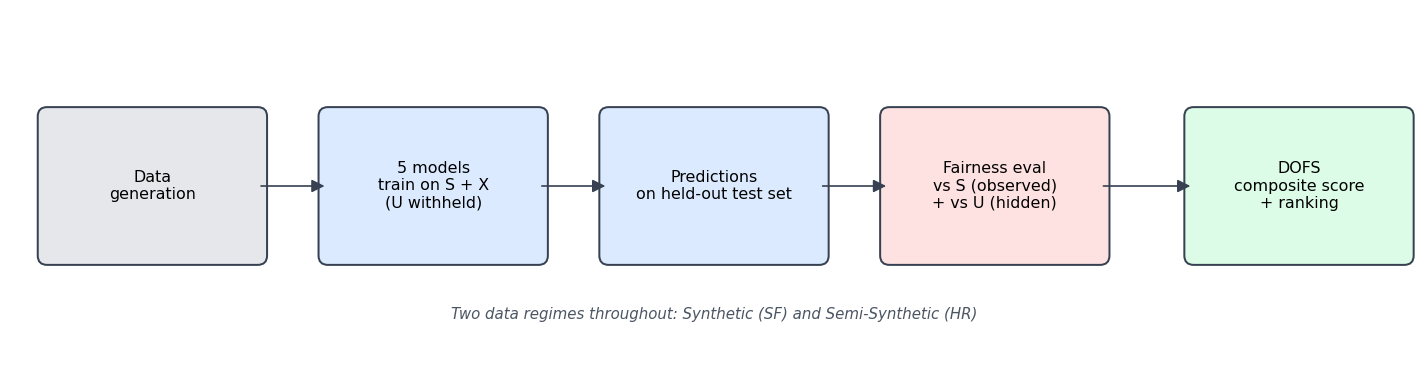

In [2]:
fig, ax = plt.subplots(figsize=(12, 3.2))
ax.set_xlim(0, 12); ax.set_ylim(0, 3); ax.axis('off')

boxes = [
    (0.3, "Data\ngeneration", "#e5e7eb"),
    (2.7, "5 models\ntrain on S + X\n(U withheld)", "#dbeafe"),
    (5.1, "Predictions\non held-out test set", "#dbeafe"),
    (7.5, "Fairness eval\nvs S (observed)\n+ vs U (hidden)", "#fee2e2"),
    (10.1, "DOFS\ncomposite score\n+ ranking", "#dcfce7"),
]
for x, label, color in boxes:
    box = FancyBboxPatch((x, 0.9), 1.8, 1.2, boxstyle="round,pad=0.08",
                          linewidth=1.2, edgecolor="#374151", facecolor=color)
    ax.add_patch(box)
    ax.text(x + 0.9, 1.5, label, ha='center', va='center', fontsize=9.5)

for x0, x1 in [(2.1, 2.7), (4.5, 5.1), (6.9, 7.5), (9.3, 10.1)]:
    ax.add_patch(FancyArrowPatch((x0, 1.5), (x1, 1.5), arrowstyle='-|>', mutation_scale=16, color="#374151"))

ax.text(6, 0.35, "Two data regimes throughout: Synthetic (SF) and Semi-Synthetic (HR)",
        ha='center', fontsize=9, style='italic', color="#4b5563")

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'workflow_overview.png'), bbox_inches='tight')
plt.show()


## 2. Load & parse results<a id="sec2"></a>

Synthetic (SF) filenames encode `base_nodes`, `u_frac`, `seed` — parsed out below. Semi-synthetic (HR) files already carry `bias_level`, `data_type`, `threshold`, `n_U` as columns; only `seed` needs parsing.

In [3]:
def parse_syn_name(name):
    d = {}
    d['sample_size_label'] = 'Large' if 'Large' in name else ('Small' if 'Small' in name else None)
    m2 = re.search(r'(\d+)_base_nodes', name)
    d['base_nodes'] = int(m2.group(1)) if m2 else None
    m3 = re.search(r'u_(\d+)p(\d+)', name)
    d['u_frac'] = float(f"{m3.group(1)}.{m3.group(2)}") if m3 else None
    m4 = re.search(r'seed_(\d+)', name)
    d['seed'] = int(m4.group(1)) if m4 else None
    m5 = re.search(r'(\d+)_nodes_full_data', name)
    d['total_nodes'] = int(m5.group(1)) if m5 else None
    d['nonlinear_pattern'] = 'Linear_ReLU_50%' if 'Linear_ReLU_50%' in name else ('Linear_100%' if 'Linear' in name and 'ReLU' not in name else name)
    return d

def parse_semi_seed(name):
    m = re.search(r'Seed(\d+)', name)
    return int(m.group(1)) if m else None

def load_all():
    dfs_syn = []
    for model, fname in SYN_FILES.items():
        path = os.path.join(DATA_DIR, fname)
        df = pd.read_csv(path)
        df['model_name'] = model
        meta = df['name_dataset'].apply(parse_syn_name).apply(pd.Series)
        df = pd.concat([df, meta], axis=1)
        df['regime'] = 'Synthetic (SF)'
        dfs_syn.append(df)
    syn_all = pd.concat(dfs_syn, ignore_index=True)

    dfs_semi = []
    for model, fname in SEMI_FILES.items():
        path = os.path.join(DATA_DIR, fname)
        df = pd.read_csv(path)
        df['model_name'] = model
        df['seed'] = df['name_dataset'].apply(parse_semi_seed)
        df['regime'] = 'Semi-Synthetic (HR)'
        dfs_semi.append(df)
    semi_all = pd.concat(dfs_semi, ignore_index=True)
    return syn_all, semi_all

syn_all, semi_all = load_all()
print('Synthetic (SF):', syn_all.shape, '| Semi-Synthetic (HR):', semi_all.shape)


Synthetic (SF): (400, 23) | Semi-Synthetic (HR): (6400, 21)


## 3. Composite metric — Distance to Optimal Fair Solution (DOFS)

TOPSIS-style aggregation of 8 metrics (5 predictive + 3 fairness), following Velev & Lessmann's Algorithm 1. `DIR_dist` is a symmetrized, bounded transform of Disparate Impact Ratio (`1 - min(DIR, 1/DIR)`) that safely handles undefined DIR. Reported as **predictive-only**, **fairness-only**, and **combined**.

In [4]:
def add_dofs(df):
    df = df.copy()
    dir_ = df['Disparate_Impact_Ratio'].replace([np.inf, -np.inf], np.nan)
    sym = np.minimum(dir_, 1 / dir_.replace(0, np.nan))
    sym = sym.fillna(0)
    df['DIR_dist'] = 1 - sym

    maximize_cols = ['ROC_AUC', 'Accuracy', 'Precision', 'Recall', 'F1_Score']
    minimize_cols = ['Statistical_Parity_Diff_(ATE)', 'Equal_Opportunity_Diff', 'DIR_dist']
    for c in minimize_cols:
        df[c + '_clip'] = df[c].clip(0, 1)

    best_components, worst_components = [], []
    for c in maximize_cols:
        best_components.append((1 - df[c]) ** 2)
        worst_components.append((0 - df[c]) ** 2)
    for c in minimize_cols:
        v = df[c + '_clip']
        best_components.append((0 - v) ** 2)
        worst_components.append((1 - v) ** 2)
    dist_best = np.sqrt(sum(best_components))
    dist_worst = np.sqrt(sum(worst_components))
    df['DOFS'] = dist_worst / (dist_worst + dist_best)

    pbest = np.sqrt(sum((1 - df[c]) ** 2 for c in maximize_cols))
    pworst = np.sqrt(sum((0 - df[c]) ** 2 for c in maximize_cols))
    df['DOFS_predictive'] = pworst / (pworst + pbest)

    fbest = np.sqrt(sum((0 - df[c + '_clip']) ** 2 for c in minimize_cols))
    fworst = np.sqrt(sum((1 - df[c + '_clip']) ** 2 for c in minimize_cols))
    df['DOFS_fairness'] = fworst / (fworst + fbest)
    return df

syn_all = add_dofs(syn_all)
semi_all = add_dofs(semi_all)
syn_all.to_csv(os.path.join(TABLES_DIR, 'synthetic_SF_with_DOFS.csv'), index=False)
semi_all.to_csv(os.path.join(TABLES_DIR, 'semi_synthetic_HR_with_DOFS.csv'), index=False)
print('DOFS computed. Per-model breakdown charted in sections 5.5 / 6.6 below.')


DOFS computed. Per-model breakdown charted in sections 5.5 / 6.6 below.


## 4. Data coverage & core comparison subsets

Coverage is checked as a table, not a chart — it's a QC step, not a result. `BIASED_MASKED` only exists for SRCVAE (visible as `NaN` below); any cross-model comparison below uses only configurations **every** model was tested on.

In [5]:
cov_syn = syn_all.groupby(['model_name', 'base_nodes', 'u_frac'])['seed'].nunique().unstack(['base_nodes', 'u_frac']).reindex(MODELS)
print('Synthetic (SF): seeds available per model x (base_nodes, u_frac)')
display(cov_syn)
cov_syn.to_csv(os.path.join(TABLES_DIR, 'coverage_synthetic.csv'))

cov_semi = semi_all.groupby(['model_name', 'data_type']).size().unstack().reindex(MODELS)
print()
print('Semi-Synthetic (HR): test-run count per model x data_type')
display(cov_semi)
cov_semi.to_csv(os.path.join(TABLES_DIR, 'coverage_semi_synthetic.csv'))


Synthetic (SF): seeds available per model x (base_nodes, u_frac)


base_nodes  10              20            
u_frac     0.0 0.5 1.0 2.0 0.0 0.5 1.0 2.0
model_name                                
CFFair      10  10  10  10  10  10  10  10
CLAIRE      10  10  10  10  10  10  10  10
SRCVAE      10  10  10  10  10  10  10  10
XGBoost     10  10  10  10  10  10  10  10
FairPFN     10  10  10  10  10  10  10  10


Semi-Synthetic (HR): test-run count per model x data_type


data_type,BIASED_ALL,BIASED_FAIRNESS,BIASED_MASKED,FAIR_ALL
model_name,,,,
CFFair,400.0,400.0,NaN,400.0
CLAIRE,400.0,400.0,NaN,400.0
SRCVAE,400.0,400.0,400.0,400.0
XGBoost,400.0,400.0,NaN,400.0
FairPFN,400.0,400.0,NaN,400.0


In [6]:
# Synthetic core subset: all 5 models now have full u_frac coverage (0.0, 0.5, 1.0, 2.0)
# -- confirmed against the current CSVs, so the core subset is the full dataset (no filtering needed).
syn_core = syn_all.copy()

# Semi-synthetic core subset: BIASED_MASKED is only run for SRCVAE, and n_U has both 0 and 4.
# Restrict to what every model shares: data_type in {BIASED_ALL, FAIR_ALL}, n_U == 4.
semi_core = semi_all[(semi_all['data_type'].isin(['BIASED_ALL', 'FAIR_ALL'])) & (semi_all['n_U'] == 4)].copy()

syn_core.to_csv(os.path.join(TABLES_DIR, 'synthetic_core_subset.csv'), index=False)
semi_core.to_csv(os.path.join(TABLES_DIR, 'semi_synthetic_core_subset.csv'), index=False)

print('Synthetic core subset — rows per model:')
print(syn_core.groupby('model_name').size())
print()
print('Semi-synthetic core subset — rows per model:')
print(semi_core.groupby('model_name').size())


Synthetic core subset — rows per model:
model_name
CFFair     80
CLAIRE     80
FairPFN    80
SRCVAE     80
XGBoost    80
dtype: int64

Semi-synthetic core subset — rows per model:
model_name
CFFair     800
CLAIRE     800
FairPFN    800
SRCVAE     800
XGBoost    800
dtype: int64


# Part 2: Core Results

## 6. Synthetic (SF) Data

All charts in this section use one consistent colour per model, matching Section 7 for direct
visual comparison across regimes.

### 6.1 Predictive performance vs. confounding ratio (u_frac)

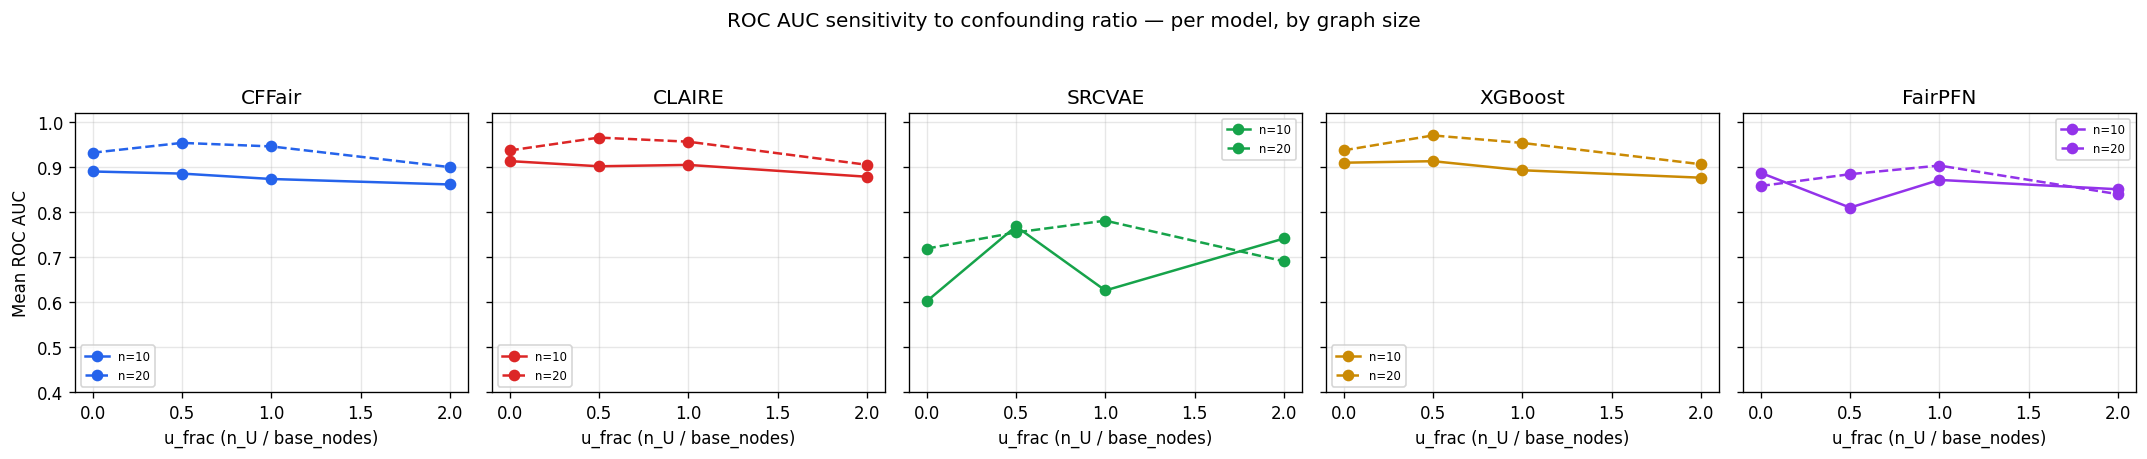

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6), sharey=True)
for ax, model in zip(axes, MODELS):
    sub = syn_all[syn_all.model_name == model]
    for bn, ls in zip([10, 20], ['-', '--']):
        s2 = sub[sub.base_nodes == bn].groupby('u_frac')['ROC_AUC'].mean()
        if len(s2):
            ax.plot(s2.index, s2.values, marker='o', linestyle=ls, color=COLORS[model], label=f'n={bn}')
    ax.set_title(model); ax.set_xlabel('u_frac (n_U / base_nodes)')
    ax.set_ylim(0.4, 1.02); ax.grid(alpha=0.3); ax.legend(fontsize=7)
axes[0].set_ylabel('Mean ROC AUC')
plt.suptitle('ROC AUC sensitivity to confounding ratio — per model, by graph size', y=1.05)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'syn_rocauc_smallmultiple.png'), bbox_inches='tight')
plt.show()


### 6.2 Fairness gap vs. confounding ratio

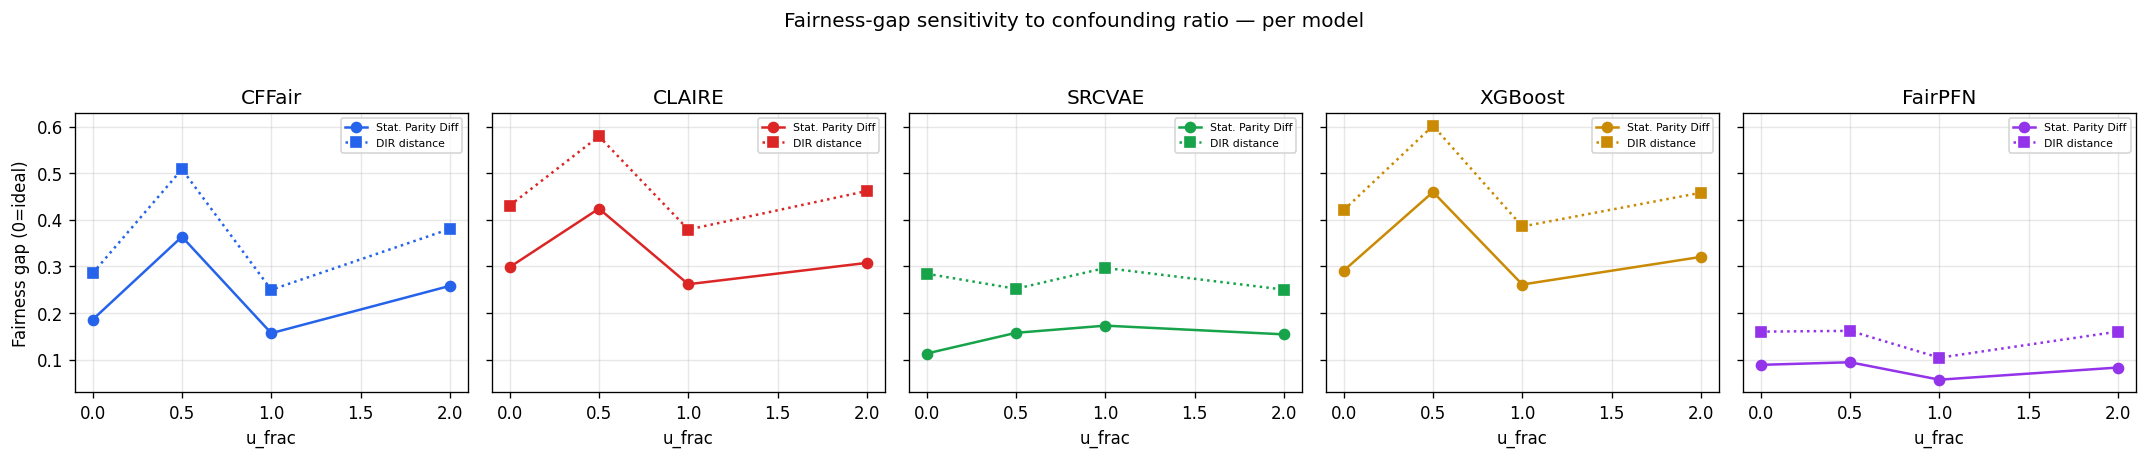

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6), sharey=True)
for ax, model in zip(axes, MODELS):
    sub = syn_all[syn_all.model_name == model]
    s2 = sub.groupby('u_frac')['Statistical_Parity_Diff_(ATE)'].mean()
    s3 = sub.groupby('u_frac')['DIR_dist'].mean()
    ax.plot(s2.index, s2.values, marker='o', color=COLORS[model], label='Stat. Parity Diff')
    ax.plot(s3.index, s3.values, marker='s', color=COLORS[model], linestyle=':', label='DIR distance')
    ax.set_title(model); ax.set_xlabel('u_frac')
    ax.grid(alpha=0.3); ax.legend(fontsize=6.5)
axes[0].set_ylabel('Fairness gap (0=ideal)')
plt.suptitle('Fairness-gap sensitivity to confounding ratio — per model', y=1.05)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'syn_fairness_smallmultiple.png'), bbox_inches='tight')
plt.show()


> **On the shared peak at u_frac = 0.5:** a plausible explanation for every model's fairness
> gap peaking here rather than at the highest confounding ratio tested is that a moderate level
> of hidden confounding creates a data-generating process in which the confounder is entangled
> just enough with the observed features to bias predictions, without yet being weak enough to
> have little effect, or strong enough for the model's remaining observed signal to dominate
> over it. This is a hypothesis, not a confirmed mechanism, and would benefit from a dedicated
> follow-up analysis isolating confounder-feature entanglement at each u_frac level.

### 6.3 Fairness–Accuracy Frontier

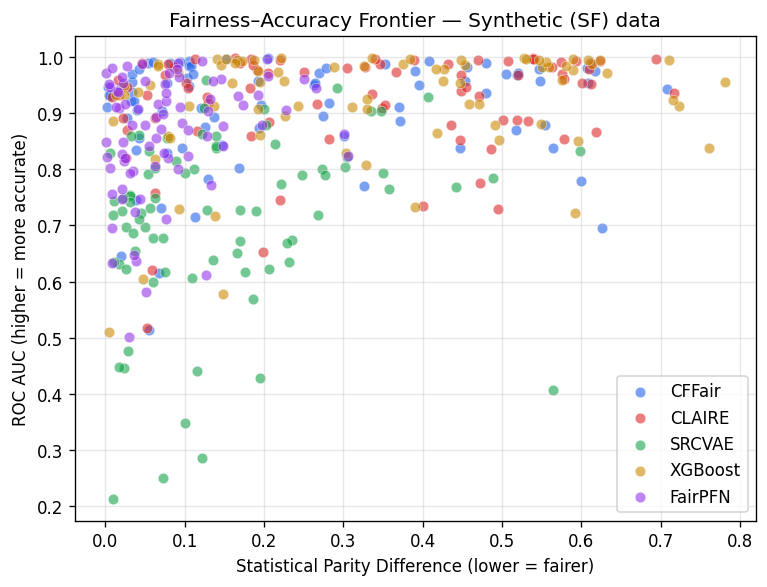

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for model in MODELS:
    sub = syn_all[syn_all.model_name == model]
    ax.scatter(sub['Statistical_Parity_Diff_(ATE)'], sub['ROC_AUC'], s=40, alpha=0.6,
               color=COLORS[model], label=model, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Statistical Parity Difference (lower = fairer)')
ax.set_ylabel('ROC AUC (higher = more accurate)')
ax.set_title('Fairness–Accuracy Frontier — Synthetic (SF) data')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'syn_frontier.png'))
plt.show()


## 7. Semi-Synthetic (HR) Data

The same three chart types used in Section 6 are repeated here for direct visual comparison
across regimes.

### 7.1 Predictive performance by bias scenario

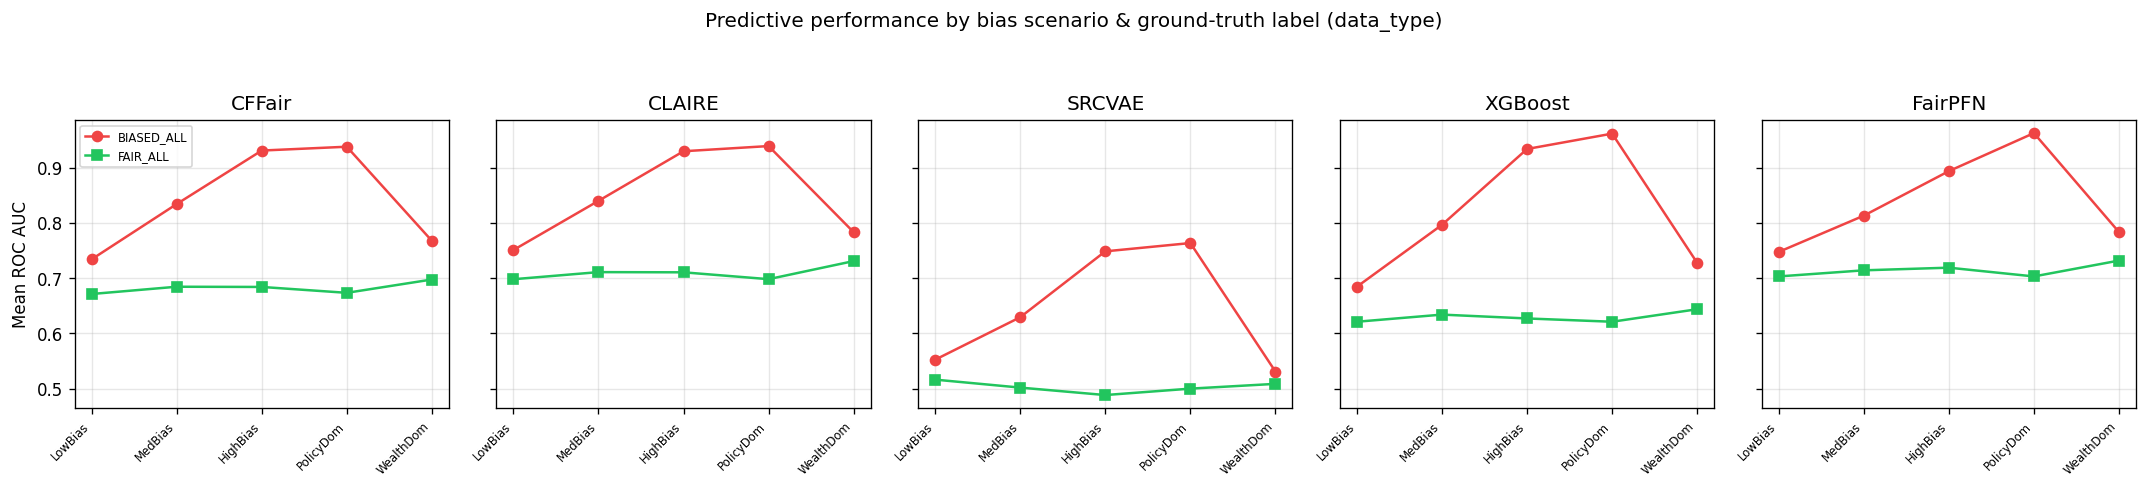

In [10]:
core_dtypes = ['BIASED_ALL', 'FAIR_ALL']
fig, axes = plt.subplots(1, 5, figsize=(18, 3.8), sharey=True)
for ax, model in zip(axes, MODELS):
    sub = semi_all[(semi_all.model_name == model) & (semi_all.data_type.isin(core_dtypes))]
    piv = sub.groupby(['bias_level', 'data_type'])['ROC_AUC'].mean().unstack().reindex(BIAS_ORDER)
    x = np.arange(len(BIAS_ORDER))
    for dt, color, marker in zip(core_dtypes, ['#ef4444', '#22c55e'], ['o', 's']):
        if dt in piv.columns:
            ax.plot(x, piv[dt].values, marker=marker, color=color, label=dt)
    ax.set_xticks(x); ax.set_xticklabels(BIAS_ORDER, rotation=45, ha='right', fontsize=7)
    ax.set_title(model); ax.grid(alpha=0.3)
    if model == 'CFFair':
        ax.legend(fontsize=7)
axes[0].set_ylabel('Mean ROC AUC')
plt.suptitle('Predictive performance by bias scenario & ground-truth label (data_type)', y=1.06)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_rocauc_smallmultiple.png'), bbox_inches='tight')
plt.show()


> **On the shared Wealth-Dominant drop:** that ROC AUC drops at Wealth-Dominant bias for
> every model without exception -- including architecturally very different approaches such as
> CLAIRE's representation-learning pipeline and FairPFN's pretrained transformer -- suggests the
> drop is a property of how the Wealth-Dominant scenario's data was generated, rather than a
> shared weakness in any one modelling approach. A likely explanation is that bias operating
> primarily through wealth-related variables produces a weaker or noisier statistical
> relationship with the observed features than bias operating through policy-related variables
> does, making the underlying signal genuinely harder for any classifier to recover.

### 7.2 Bias-detection sanity check — SPD by data_type

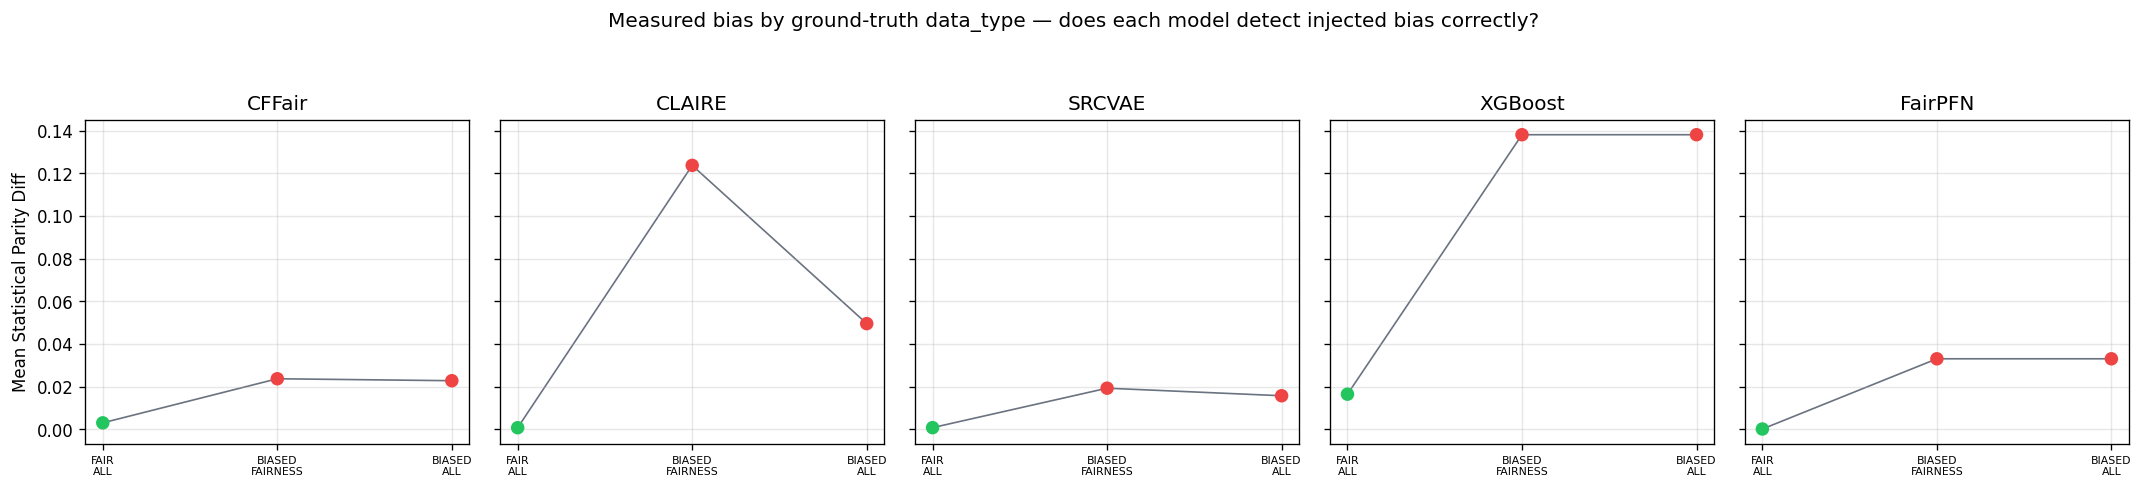

Bias-detection gap (BIASED_ALL minus FAIR_ALL, mean SPD):


data_type,BIASED_ALL,FAIR_ALL,detection_gap
model_name,,,
XGBoost,0.1381,0.0165,0.1216
CLAIRE,0.0496,0.0008,0.0488
FairPFN,0.0331,0.0002,0.0329
CFFair,0.0229,0.0031,0.0197
SRCVAE,0.0158,0.0009,0.0149


In [11]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.8), sharey=True)
for ax, model in zip(axes, MODELS):
    sub = semi_all[semi_all.model_name == model]
    piv = sub.groupby('data_type')['Statistical_Parity_Diff_(ATE)'].mean().reindex(DTYPE_ORDER).dropna()
    x = np.arange(len(piv))
    point_colors = ['#ef4444' if 'BIASED' in d else '#22c55e' for d in piv.index]
    ax.plot(x, piv.values, color='#6b7280', linewidth=1, zorder=1)
    ax.scatter(x, piv.values, color=point_colors, s=50, zorder=2)
    ax.set_xticks(x); ax.set_xticklabels([d.replace('_', '\n') for d in piv.index], fontsize=6.5)
    ax.set_title(model); ax.grid(alpha=0.3)
axes[0].set_ylabel('Mean Statistical Parity Diff')
plt.suptitle('Measured bias by ground-truth data_type — does each model detect injected bias correctly?', y=1.06)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_spd_by_datatype.png'), bbox_inches='tight')
plt.show()

print('Bias-detection gap (BIASED_ALL minus FAIR_ALL, mean SPD):')
gap = semi_all.groupby(['model_name', 'data_type'])['Statistical_Parity_Diff_(ATE)'].mean().unstack()[['BIASED_ALL', 'FAIR_ALL']]
gap['detection_gap'] = gap['BIASED_ALL'] - gap['FAIR_ALL']
display(gap.round(4).sort_values('detection_gap', ascending=False))


### 7.3 Fairness–Accuracy Frontier

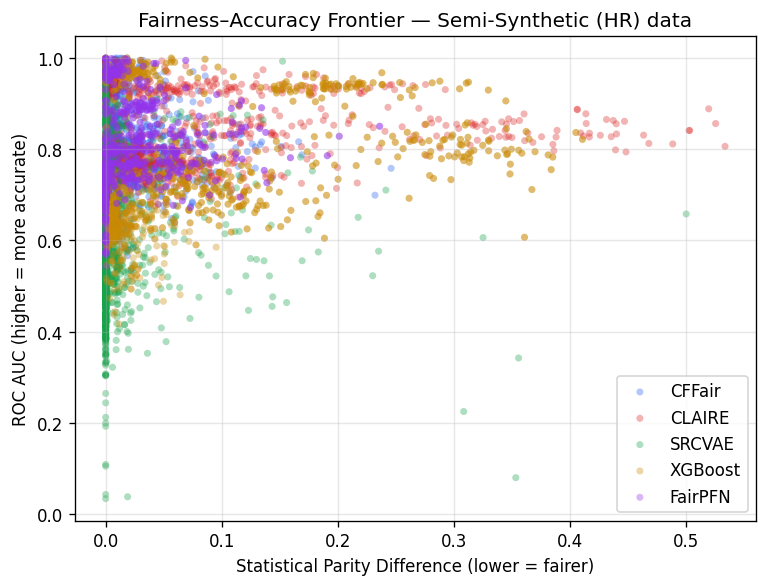

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for model in MODELS:
    sub = semi_all[semi_all.model_name == model]
    ax.scatter(sub['Statistical_Parity_Diff_(ATE)'], sub['ROC_AUC'], s=18, alpha=0.35,
               color=COLORS[model], label=model, edgecolor='none')
ax.set_xlabel('Statistical Parity Difference (lower = fairer)')
ax.set_ylabel('ROC AUC (higher = more accurate)')
ax.set_title('Fairness–Accuracy Frontier — Semi-Synthetic (HR) data')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_frontier.png'))
plt.show()


## 8. DOFS on Average, Both Simulation Types

DOFS (Distance to the Optimal Fair Solution) combines all five predictive metrics and three
fairness metrics into a single score between 0 and 1, following the TOPSIS-inspired
methodology of Velev and Lessmann (2026). Reported here purely as tabular overviews, per the
thesis's requested structure -- no chart, since the per-regime breakdown is already shown
visually in Sections 6 and 7.

See Appendix A (Part 3, Section 12) for a sensitivity analysis of which experimental factors
most strongly drive variation in DOFS.

In [13]:
dofs_syn_means = syn_core.groupby('model_name')[['DOFS', 'DOFS_predictive', 'DOFS_fairness']].mean().reindex(MODELS)
dofs_semi_means = semi_core.groupby('model_name')[['DOFS', 'DOFS_predictive', 'DOFS_fairness']].mean().reindex(MODELS)

dofs_avg_table = pd.DataFrame({
    'DOFS (SF)': dofs_syn_means['DOFS'],
    'DOFS (HR)': dofs_semi_means['DOFS'],
    'Average (SF+HR)': (dofs_syn_means['DOFS'] + dofs_semi_means['DOFS']) / 2,
    'DOFS-predictive (SF)': dofs_syn_means['DOFS_predictive'],
    'DOFS-fairness (SF)': dofs_syn_means['DOFS_fairness'],
    'DOFS-predictive (HR)': dofs_semi_means['DOFS_predictive'],
    'DOFS-fairness (HR)': dofs_semi_means['DOFS_fairness'],
}).reindex(MODELS)

print('=== DOFS on average, both simulation types ===')
display(dofs_avg_table.round(3))
dofs_avg_table.to_csv(os.path.join(TABLES_DIR, 'dofs_average_both_regimes.csv'))


=== DOFS on average, both simulation types ===


,DOFS (SF),DOFS (HR),Average (SF+HR),DOFS-predictive (SF),DOFS-fairness (SF),DOFS-predictive (HR),DOFS-fairness (HR)
model_name,,,,,,,
CFFair,0.792,0.822,0.807,0.850,0.752,0.785,0.934
CLAIRE,0.766,0.809,0.787,0.865,0.678,0.782,0.897
SRCVAE,0.702,0.732,0.717,0.659,0.800,0.673,0.894
XGBoost,0.765,0.784,0.775,0.871,0.672,0.771,0.849
FairPFN,0.820,0.814,0.817,0.800,0.878,0.781,0.912


## 9. Fairness with Respect to Hidden Confounders (U)

Every result reported above evaluates fairness with respect to the observed protected
attribute S -- the standard approach in the fairness literature. This section addresses the
question central to this project's contribution: how do the same models compare on fairness
with respect to the confounding attributes that were deliberately withheld from training?

> **On the k-means clustering used below:** because the two comparison groups are defined by an
> unsupervised clustering step rather than a known ground-truth grouping, their validity depends
> on the hidden attributes actually separating into two reasonably distinct, balanced groups.
> Heavily skewed clusters, where they occur, would understate rather than overstate the measured
> U-fairness gap, since a near-empty cluster mechanically produces smaller absolute differences
> in prediction rate -- so the S-to-U gap reported below, if anything, likely represents a
> conservative estimate of the true disparity with respect to hidden attributes.

**Note:** all computations below use `syn_core` / `semi_core` (the same matched row subset used
throughout Sections 6-8), not the full `syn_all` / `semi_all` datasets -- ensuring every number
in this section is directly comparable to Sections 6-8.

### 9.1 Load & merge U-fairness data

In [14]:
U_SYN_FILES = {m: f"{m}_syn_U_fairness.csv" for m in MODELS}
U_SEMI_FILES = {m: f"{m}_semi_syn_U_fairness.csv" for m in MODELS}

def load_u_fairness(file_map):
    dfs = []
    for model, fname in file_map.items():
        path = os.path.join(DATA_DIR, fname)
        if not os.path.isfile(path):
            print(f"  [MISSING] {fname} -- skipping {model}.")
            continue
        df = pd.read_csv(path)
        dfs.append(df)
    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)

u_syn = load_u_fairness(U_SYN_FILES)
u_semi = load_u_fairness(U_SEMI_FILES)
print('U-fairness loaded --  Synthetic:', u_syn.shape, '| Semi-Synthetic:', u_semi.shape)

u_cols_to_merge = ['model_name', 'name_dataset', 'Statistical_Parity_Diff_wrt_U',
                    'Disparate_Impact_Ratio_wrt_U', 'Equal_Opportunity_Diff_wrt_U']

# Merge into the CORE subsets (not the full syn_all/semi_all), so every downstream
# S-vs-U computation below uses the identical row set as Sections 6-8.
# syn_core == syn_all already (full synthetic coverage), so this changes nothing there;
# semi_core is the real fix -- it excludes BIASED_FAIRNESS / BIASED_MASKED / n_U==0 rows
# that semi_all still included, which previously caused a small mismatch against Section 7's tables.
syn_core = syn_core.merge(u_syn[u_cols_to_merge], on=['model_name', 'name_dataset'], how='left')
semi_core = semi_core.merge(u_semi[u_cols_to_merge], on=['model_name', 'name_dataset'], how='left')

# Sanity check: row counts should be unchanged by the merge (left join, no duplication)
print('syn_core rows:', len(syn_core), '| semi_core rows:', len(semi_core))


U-fairness loaded --  Synthetic: (300, 11) | Semi-Synthetic: (4000, 11)
syn_core rows: 400 | semi_core rows: 4000


In [15]:
def add_dofs_u(df):
    """Computes DIR_dist_U and DOFS_U (the U-based counterpart of DOFS) for a dataframe
    that already has the *_wrt_U columns merged in (see the cell above)."""
    df = df.copy()
    dir_u = df['Disparate_Impact_Ratio_wrt_U'].replace([np.inf, -np.inf], np.nan)
    sym_u = np.minimum(dir_u, 1 / dir_u.replace(0, np.nan)).fillna(0)
    df['DIR_dist_U'] = 1 - sym_u

    maximize_cols = ['ROC_AUC', 'Accuracy', 'Precision', 'Recall', 'F1_Score']
    minimize_cols_u = ['Statistical_Parity_Diff_wrt_U', 'Equal_Opportunity_Diff_wrt_U', 'DIR_dist_U']
    for c in minimize_cols_u:
        df[c + '_clip'] = df[c].clip(0, 1)

    best_components, worst_components = [], []
    for c in maximize_cols:
        best_components.append((1 - df[c]) ** 2)
        worst_components.append((0 - df[c]) ** 2)
    for c in minimize_cols_u:
        v = df[c + '_clip']
        best_components.append((0 - v) ** 2)
        worst_components.append((1 - v) ** 2)
    dist_best = np.sqrt(sum(best_components))
    dist_worst = np.sqrt(sum(worst_components))
    df['DOFS_U'] = dist_worst / (dist_worst + dist_best)
    return df

# Computed here (immediately after the merge) so DIR_dist_U and DOFS_U are available
# to every subsequent cell in this section, in normal top-to-bottom run order.
syn_core = add_dofs_u(syn_core)
semi_core = add_dofs_u(semi_core)
print('DOFS_U computed. syn_core columns now include DIR_dist_U, DOFS_U:',
      'DOFS_U' in syn_core.columns and 'DOFS_U' in semi_core.columns)


DOFS_U computed. syn_core columns now include DIR_dist_U, DOFS_U: True


### 9.2 S-fairness vs. U-fairness, by model

In [16]:
summary = pd.DataFrame({
    'SPD_wrt_S (Synthetic)': syn_core.groupby('model_name')['Statistical_Parity_Diff_(ATE)'].mean(),
    'SPD_wrt_U (Synthetic)': syn_core.groupby('model_name')['Statistical_Parity_Diff_wrt_U'].mean(),
    'SPD_wrt_S (Semi-Synthetic)': semi_core.groupby('model_name')['Statistical_Parity_Diff_(ATE)'].mean(),
    'SPD_wrt_U (Semi-Synthetic)': semi_core.groupby('model_name')['Statistical_Parity_Diff_wrt_U'].mean(),
}).reindex(MODELS)
display(summary.round(4))
summary.to_csv(os.path.join(TABLES_DIR, 'S_vs_U_fairness_summary.csv'))


,SPD_wrt_S (Synthetic),SPD_wrt_U (Synthetic),SPD_wrt_S (Semi-Synthetic),SPD_wrt_U (Semi-Synthetic)
model_name,,,,
CFFair,0.2412,0.5881,0.0130,0.1406
CLAIRE,0.3230,0.6403,0.0252,0.1100
SRCVAE,0.1495,0.2628,0.0083,0.0197
XGBoost,0.3331,0.6296,0.0773,0.1609
FairPFN,0.0809,0.4927,0.0167,0.1194


### 9.3 U-fairness trend across scenarios

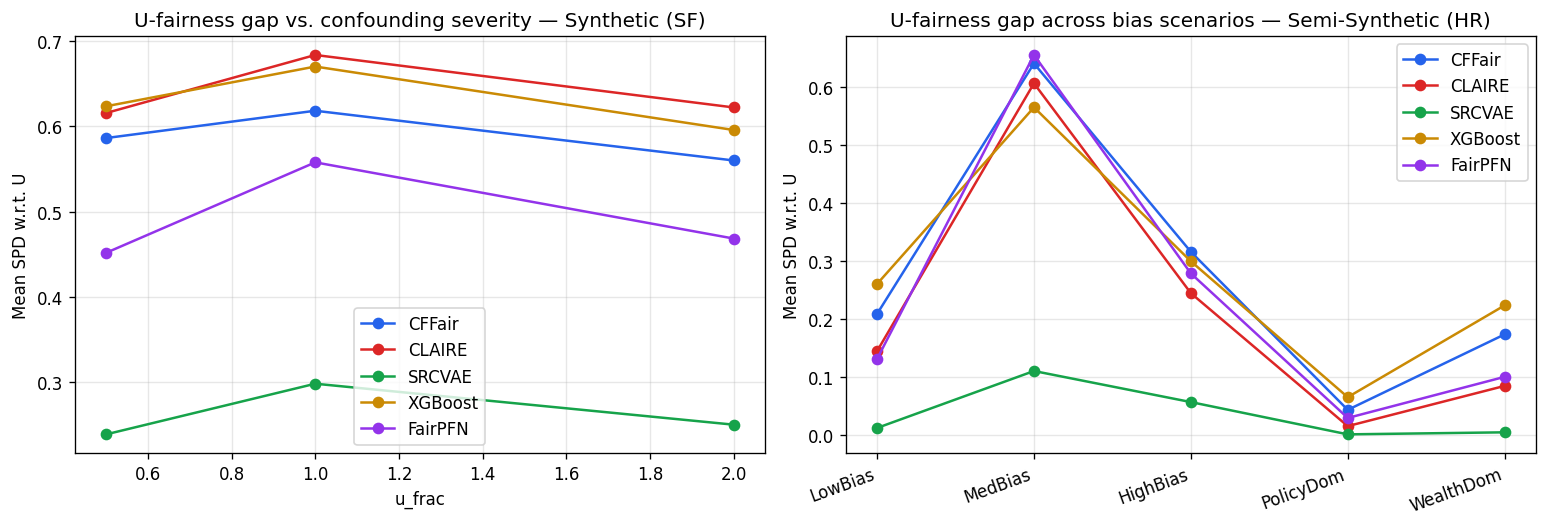

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for model in MODELS:
    sub = syn_core[syn_core.model_name == model].groupby('u_frac')['Statistical_Parity_Diff_wrt_U'].mean()
    axes[0].plot(sub.index, sub.values, marker='o', color=COLORS[model], label=model)
axes[0].set_xlabel('u_frac'); axes[0].set_ylabel('Mean SPD w.r.t. U')
axes[0].set_title('U-fairness gap vs. confounding severity — Synthetic (SF)')
axes[0].grid(alpha=0.3); axes[0].legend()

for model in MODELS:
    sub = semi_core[(semi_core.model_name == model) & (semi_core.data_type == 'BIASED_ALL')]
    s = sub.groupby('bias_level')['Statistical_Parity_Diff_wrt_U'].mean().reindex(BIAS_ORDER)
    axes[1].plot(range(len(s)), s.values, marker='o', color=COLORS[model], label=model)
axes[1].set_xticks(range(len(BIAS_ORDER))); axes[1].set_xticklabels(BIAS_ORDER, rotation=20, ha='right')
axes[1].set_ylabel('Mean SPD w.r.t. U'); axes[1].set_title('U-fairness gap across bias scenarios — Semi-Synthetic (HR)')
axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'u_fairness_trend.png'))
plt.show()


### 9.4 The core comparison: is a model fair on S also fair on U?

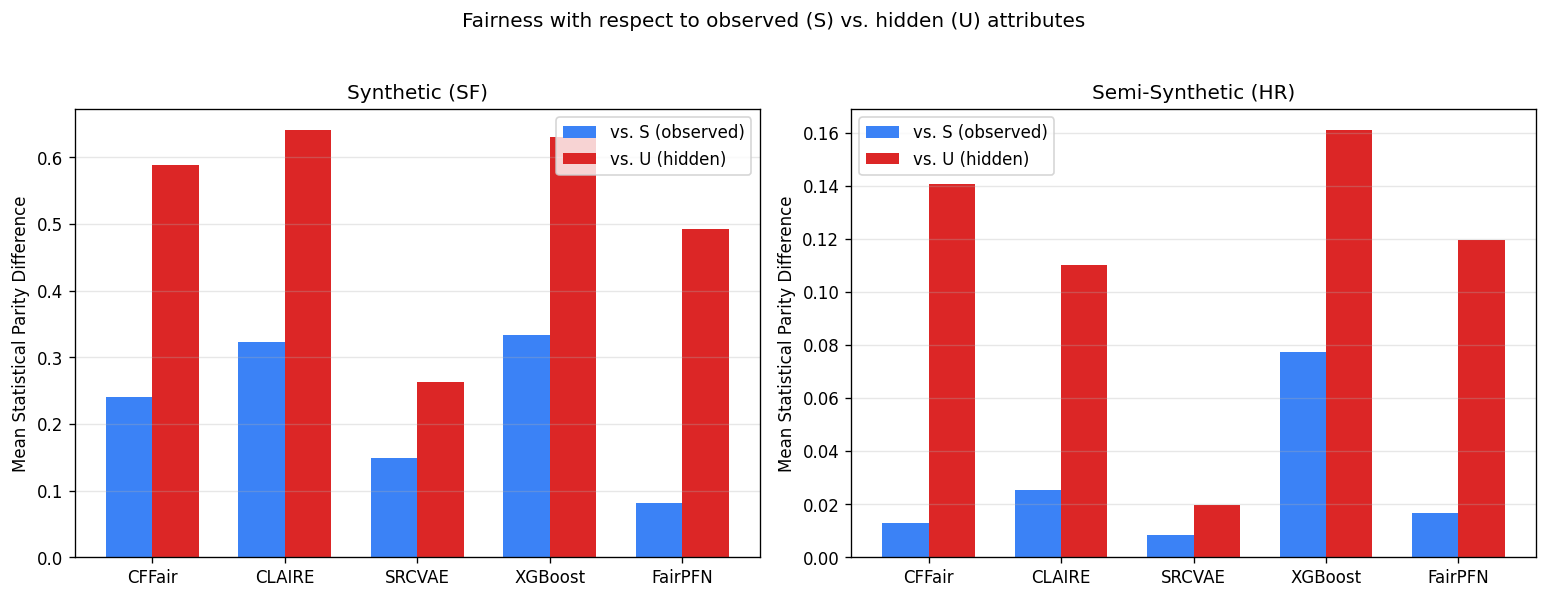

In [18]:
syn_means_u = syn_core.groupby('model_name')[['Statistical_Parity_Diff_(ATE)', 'Statistical_Parity_Diff_wrt_U']].mean().reindex(MODELS)
semi_means_u = semi_core.groupby('model_name')[['Statistical_Parity_Diff_(ATE)', 'Statistical_Parity_Diff_wrt_U']].mean().reindex(MODELS)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
x = np.arange(len(MODELS)); w = 0.35

axes[0].bar(x - w/2, syn_means_u['Statistical_Parity_Diff_(ATE)'], width=w, label='vs. S (observed)', color='#3b82f6')
axes[0].bar(x + w/2, syn_means_u['Statistical_Parity_Diff_wrt_U'], width=w, label='vs. U (hidden)', color='#dc2626')
axes[0].set_xticks(x); axes[0].set_xticklabels(MODELS)
axes[0].set_ylabel('Mean Statistical Parity Difference')
axes[0].set_title('Synthetic (SF)')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(x - w/2, semi_means_u['Statistical_Parity_Diff_(ATE)'], width=w, label='vs. S (observed)', color='#3b82f6')
axes[1].bar(x + w/2, semi_means_u['Statistical_Parity_Diff_wrt_U'], width=w, label='vs. U (hidden)', color='#dc2626')
axes[1].set_xticks(x); axes[1].set_xticklabels(MODELS)
axes[1].set_ylabel('Mean Statistical Parity Difference')
axes[1].set_title('Semi-Synthetic (HR)')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Fairness with respect to observed (S) vs. hidden (U) attributes', y=1.03)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 's_vs_u_fairness_comparison.png'))
plt.show()


### 9.5 Statistical test: is the S→U fairness gap significant?

Paired Wilcoxon signed-rank test — each dataset's `SPD_wrt_S` compared against its own
`SPD_wrt_U`, per model. Non-parametric, appropriate since fairness metrics aren't guaranteed
normally distributed.

In [19]:
from scipy.stats import wilcoxon

def run_wilcoxon(df, label):
    print(f'=== {label}: Wilcoxon signed-rank test (SPD_wrt_S vs SPD_wrt_U) ===')
    results = []
    for model in MODELS:
        sub = df[df.model_name == model][['Statistical_Parity_Diff_(ATE)', 'Statistical_Parity_Diff_wrt_U']].dropna()
        if len(sub) < 5:
            print(f'  {model}: insufficient paired samples (n={len(sub)}), skipping.')
            continue
        stat, p = wilcoxon(sub['Statistical_Parity_Diff_wrt_U'], sub['Statistical_Parity_Diff_(ATE)'], alternative='greater')
        median_gap = (sub['Statistical_Parity_Diff_wrt_U'] - sub['Statistical_Parity_Diff_(ATE)']).median()
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
        print(f'  {model}: n={len(sub)} | median gap={median_gap:.4f} | p={p:.2e} {sig}')
        results.append({'model_name': model, 'n': len(sub), 'median_gap': median_gap, 'p_value': p, 'significant': p < 0.05})
    result_df = pd.DataFrame(results)
    result_df.to_csv(os.path.join(TABLES_DIR, f'wilcoxon_{label.replace(" ", "_").lower()}.csv'), index=False)
    return result_df

wilcoxon_syn = run_wilcoxon(syn_core, 'Synthetic')
print()
wilcoxon_semi = run_wilcoxon(semi_core, 'Semi-Synthetic')


=== Synthetic: Wilcoxon signed-rank test (SPD_wrt_S vs SPD_wrt_U) ===
  CFFair: n=60 | median gap=0.2834 | p=1.28e-10 ***
  CLAIRE: n=60 | median gap=0.2707 | p=4.21e-11 ***
  SRCVAE: n=60 | median gap=0.0756 | p=1.89e-07 ***
  XGBoost: n=60 | median gap=0.2470 | p=5.71e-10 ***
  FairPFN: n=60 | median gap=0.4433 | p=1.22e-11 ***

=== Semi-Synthetic: Wilcoxon signed-rank test (SPD_wrt_S vs SPD_wrt_U) ===
  CFFair: n=800 | median gap=0.0107 | p=3.52e-90 ***
  CLAIRE: n=800 | median gap=0.0011 | p=1.20e-73 ***
  SRCVAE: n=800 | median gap=0.0000 | p=2.57e-05 ***
  XGBoost: n=800 | median gap=0.0369 | p=8.05e-115 ***
  FairPFN: n=800 | median gap=0.0000 | p=6.91e-67 ***


> **Reading the p-values above:** all 10 tests are significant at p<0.001, but magnitude matters more than stars here. Synthetic median gaps are large (0.08–0.44) — a real, substantial effect. Semi-synthetic median gaps are often near zero (SRCVAE, FairPFN ≈ 0.0000) yet still significant, purely because n=800 makes even tiny effects detectable. XGBoost is the clear semi-synthetic exception, with a gap (0.037) large enough to matter in both senses.

### 9.6 Rank correlation: does the model ranking change between S and U fairness?

In [20]:
def rank_correlation_check(df, label):
    means = df.groupby('model_name')[['Statistical_Parity_Diff_(ATE)', 'Statistical_Parity_Diff_wrt_U']].mean().reindex(MODELS)
    rank_s = means['Statistical_Parity_Diff_(ATE)'].rank()
    rank_u = means['Statistical_Parity_Diff_wrt_U'].rank()
    rho, p = spearmanr(rank_s, rank_u)
    print(f'{label}: Spearman rho between S-ranking and U-ranking = {rho:.3f} (p={p:.3f})')
    comparison = pd.DataFrame({'rank_by_S': rank_s.astype(int), 'rank_by_U': rank_u.astype(int)})
    display(comparison)
    return rho, p

print('Low/negative rho = model ranking materially changes depending on which fairness metric is used.\n')
rho_syn, p_syn = rank_correlation_check(syn_core, 'Synthetic')
print()
rho_semi, p_semi = rank_correlation_check(semi_core, 'Semi-Synthetic')


Low/negative rho = model ranking materially changes depending on which fairness metric is used.

Synthetic: Spearman rho between S-ranking and U-ranking = 0.800 (p=0.104)


,rank_by_S,rank_by_U
model_name,,
CFFair,3,3
CLAIRE,4,5
SRCVAE,2,1
XGBoost,5,4
FairPFN,1,2



Semi-Synthetic: Spearman rho between S-ranking and U-ranking = 0.600 (p=0.285)


,rank_by_S,rank_by_U
model_name,,
CFFair,2,4
CLAIRE,4,2
SRCVAE,1,1
XGBoost,5,5
FairPFN,3,3


### 9.7 Per-configuration scatter: SPD_wrt_S vs SPD_wrt_U

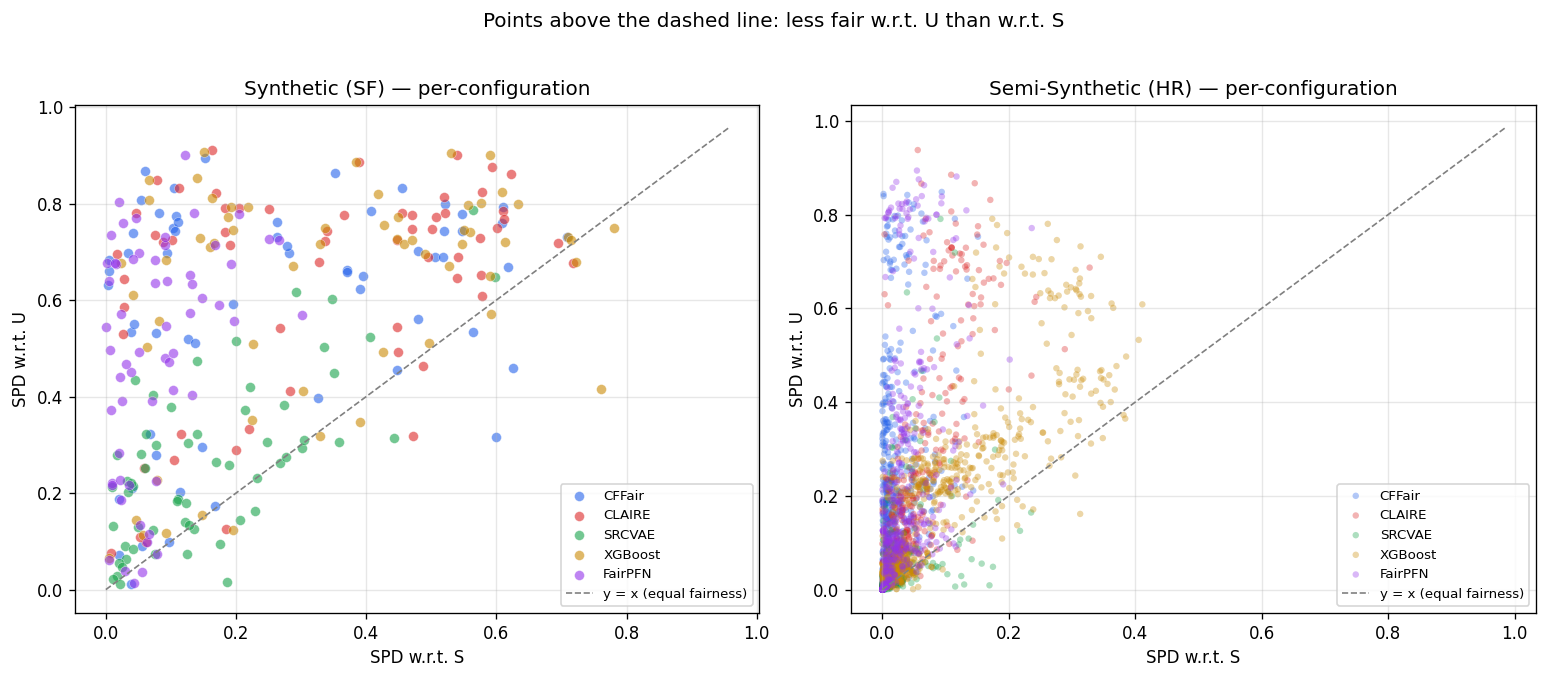

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for model in MODELS:
    sub = syn_core[syn_core.model_name == model]
    axes[0].scatter(sub['Statistical_Parity_Diff_(ATE)'], sub['Statistical_Parity_Diff_wrt_U'],
                     s=35, alpha=0.6, color=COLORS[model], label=model, edgecolor='white', linewidth=0.3)
lims = [0, max(syn_core['Statistical_Parity_Diff_(ATE)'].max(), syn_core['Statistical_Parity_Diff_wrt_U'].max()) * 1.05]
axes[0].plot(lims, lims, '--', color='gray', linewidth=1, label='y = x (equal fairness)')
axes[0].set_xlabel('SPD w.r.t. S'); axes[0].set_ylabel('SPD w.r.t. U')
axes[0].set_title('Synthetic (SF) — per-configuration'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for model in MODELS:
    sub = semi_core[semi_core.model_name == model]
    axes[1].scatter(sub['Statistical_Parity_Diff_(ATE)'], sub['Statistical_Parity_Diff_wrt_U'],
                     s=15, alpha=0.35, color=COLORS[model], label=model, edgecolor='none')
lims2 = [0, max(semi_core['Statistical_Parity_Diff_(ATE)'].max(), semi_core['Statistical_Parity_Diff_wrt_U'].max()) * 1.05]
axes[1].plot(lims2, lims2, '--', color='gray', linewidth=1, label='y = x (equal fairness)')
axes[1].set_xlabel('SPD w.r.t. S'); axes[1].set_ylabel('SPD w.r.t. U')
axes[1].set_title('Semi-Synthetic (HR) — per-configuration'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle('Points above the dashed line: less fair w.r.t. U than w.r.t. S', y=1.02)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 's_vs_u_scatter.png'))
plt.show()


### 9.8 Which fairness component drives the gap?

Confirms whether SPD, EOD, and DIR distance all degrade with respect to U, or whether the
pattern above is driven by one metric alone.

=== Synthetic: component-level S vs U comparison ===


,SPD (S),SPD (U),EOD (S),EOD (U),DIR_dist (S),DIR_dist (U),SPD gap (U-S),EOD gap (U-S),DIR_dist gap (U-S)
model_name,,,,,,,,,
CFFair,0.2412,0.5881,0.1146,0.2543,0.3560,0.7805,0.3469,0.1396,0.4245
CLAIRE,0.3230,0.6403,0.1528,0.3102,0.4627,0.8158,0.3173,0.1574,0.3531
SRCVAE,0.1495,0.2628,0.1395,0.1852,0.2709,0.5456,0.1133,0.0457,0.2747
XGBoost,0.3331,0.6296,0.1555,0.2742,0.4667,0.8012,0.2965,0.1186,0.3345
FairPFN,0.0809,0.4927,0.1060,0.2545,0.1466,0.7099,0.4118,0.1485,0.5633



=== Semi-Synthetic: component-level S vs U comparison ===


,SPD (S),SPD (U),EOD (S),EOD (U),DIR_dist (S),DIR_dist (U),SPD gap (U-S),EOD gap (U-S),DIR_dist gap (U-S)
model_name,,,,,,,,,
CFFair,0.0130,0.1406,0.0709,0.1595,0.0888,0.3214,0.1276,0.0886,0.2326
CLAIRE,0.0252,0.1100,0.0466,0.1127,0.1938,0.3037,0.0847,0.0661,0.1099
SRCVAE,0.0083,0.0197,0.0107,0.0233,0.2372,0.2688,0.0113,0.0126,0.0316
XGBoost,0.0773,0.1609,0.0956,0.1825,0.2578,0.3394,0.0835,0.0869,0.0817
FairPFN,0.0167,0.1194,0.0653,0.1381,0.1462,0.3080,0.1028,0.0728,0.1618


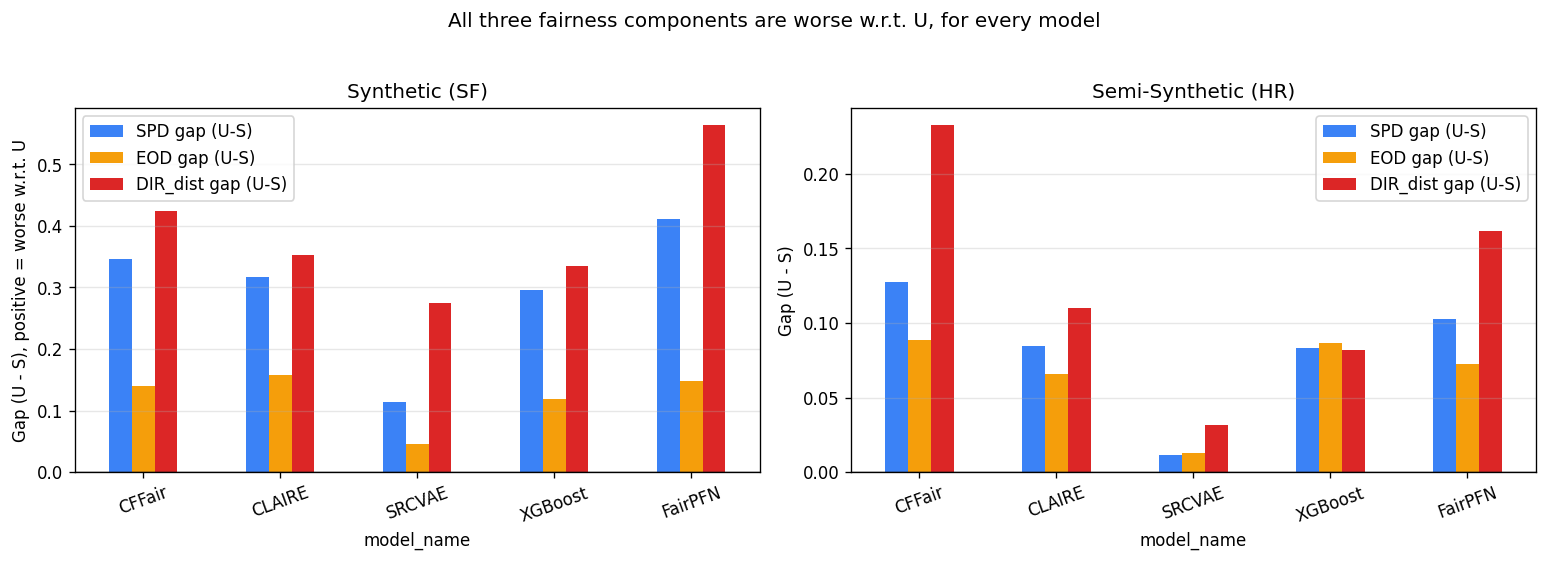

In [22]:
def component_breakdown(df, label):
    comp = pd.DataFrame({
        'SPD (S)': df.groupby('model_name')['Statistical_Parity_Diff_(ATE)'].mean(),
        'SPD (U)': df.groupby('model_name')['Statistical_Parity_Diff_wrt_U'].mean(),
        'EOD (S)': df.groupby('model_name')['Equal_Opportunity_Diff'].mean(),
        'EOD (U)': df.groupby('model_name')['Equal_Opportunity_Diff_wrt_U'].mean(),
        'DIR_dist (S)': df.groupby('model_name')['DIR_dist'].mean(),
        'DIR_dist (U)': df.groupby('model_name')['DIR_dist_U'].mean() if 'DIR_dist_U' in df.columns else np.nan,
    }).reindex(MODELS)

    comp['SPD gap (U-S)'] = comp['SPD (U)'] - comp['SPD (S)']
    comp['EOD gap (U-S)'] = comp['EOD (U)'] - comp['EOD (S)']
    comp['DIR_dist gap (U-S)'] = comp['DIR_dist (U)'] - comp['DIR_dist (S)']

    print(f'=== {label}: component-level S vs U comparison ===')
    display(comp.round(4))
    comp.to_csv(os.path.join(TABLES_DIR, f'component_breakdown_{label.replace(" ", "_").lower()}.csv'))
    return comp

# DIR_dist_U requires the DOFS_U computation (Part 3, Section 13) to have run first for the
# DIR-distance columns; SPD and EOD gaps are available immediately either way.
comp_syn = component_breakdown(syn_core, 'Synthetic')
print()
comp_semi = component_breakdown(semi_core, 'Semi-Synthetic')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
gap_cols = ['SPD gap (U-S)', 'EOD gap (U-S)', 'DIR_dist gap (U-S)']

comp_syn[gap_cols].reindex(MODELS).plot(kind='bar', ax=axes[0], color=['#3b82f6', '#f59e0b', '#dc2626'])
axes[0].set_title('Synthetic (SF)'); axes[0].set_ylabel('Gap (U - S), positive = worse w.r.t. U')
axes[0].axhline(0, color='black', linewidth=0.8); axes[0].grid(alpha=0.3, axis='y')
axes[0].set_xticklabels(MODELS, rotation=20)

comp_semi[gap_cols].reindex(MODELS).plot(kind='bar', ax=axes[1], color=['#3b82f6', '#f59e0b', '#dc2626'])
axes[1].set_title('Semi-Synthetic (HR)'); axes[1].set_ylabel('Gap (U - S)')
axes[1].axhline(0, color='black', linewidth=0.8); axes[1].grid(alpha=0.3, axis='y')
axes[1].set_xticklabels(MODELS, rotation=20)

plt.suptitle('All three fairness components are worse w.r.t. U, for every model', y=1.03)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'component_gap_bars.png'))
plt.show()


The differences in how each model responds to hidden confounding are consistent with how each
was constructed. CFFair's abduction step is defined entirely in terms of S: it fits a
regression of the observable features on S and uses the residual as the classifier's input --
a procedure that by construction can only remove S-attributable structure, with no access to U
during training and therefore no mechanism that could extend its fairness guarantee to hidden
attributes. SRCVAE, by contrast, is the only model whose fairness mechanism is not defined
directly in terms of the observed attribute: its adversary is trained against a learned latent
proxy for outcome-relevant structure rather than against S itself, a plausible explanation for
why it consistently shows the smallest S-to-U gap of the five models in both regimes. FairPFN,
as a pretrained, zero-shot transformer, is not fitted to any single dataset's specific S-Y
relationship the way the other four models are, which may explain both its unusually flat, low
fairness curves when measured against S and the fact that its ranking shifts the most between
S-based and U-based fairness. CLAIRE and XGBoost, the two models with the largest S-based
fairness gaps throughout Sections 6-7, also show large S-to-U gaps -- unsurprising for XGBoost,
which has no fairness mechanism of any kind, and suggestive for CLAIRE that its
representation-learning approach, even where it reduces S-attributable disparity, is not by
design targeted at disparity from unobserved sources either.

A parallel composite score (DOFS_U) that shows this same pattern at the level of the combined
metric, and a weight-sensitivity robustness check for the S-based DOFS ranking, are provided in
Part 3 (Sections 13-14) of this notebook.

## 10. Summary and Conclusions

In [23]:
qual_summary = pd.DataFrame({
    'Model': MODELS,
    'Avg. DOFS (SF+HR)': [round(dofs_avg_table.loc[m, 'Average (SF+HR)'], 3) for m in MODELS],
    'Mean SPD wrt S (SF)': [round(syn_means_u.loc[m, 'Statistical_Parity_Diff_(ATE)'], 4) for m in MODELS],
    'Mean SPD wrt U (SF)': [round(syn_means_u.loc[m, 'Statistical_Parity_Diff_wrt_U'], 4) for m in MODELS],
}).set_index('Model')
print('=== Final comparison snapshot (see Sections 6-9 for full detail) ===')
display(qual_summary)


=== Final comparison snapshot (see Sections 6-9 for full detail) ===


,Avg. DOFS (SF+HR),Mean SPD wrt S (SF),Mean SPD wrt U (SF)
Model,,,
CFFair,0.807,0.2412,0.5881
CLAIRE,0.787,0.3230,0.6403
SRCVAE,0.717,0.1495,0.2628
XGBoost,0.775,0.3331,0.6296
FairPFN,0.817,0.0809,0.4927


**Qualitative summary** (ratings relative to the other models in this benchmark; review and
adjust after re-running with new results):

| Model | Predictive Performance | Fairness (Observed, S) | Fairness (Hidden, U) | Key Characteristic |
|---|---|---|---|---|
| CFFair | Medium-High | Medium-High | Medium-Low | Fairness mechanism (abduction) targets S only; no pathway to generalise to U |
| CLAIRE | High | Low | Low | Strong accuracy, but among the largest gaps on both S- and U-based fairness |
| SRCVAE | Low | Medium-High | High | Most consistent across S and U (smallest S-to-U gap); weakest predictive accuracy |
| XGBoost *(baseline, no fairness mechanism)* | High | Low | Low | Reference point only; not a fairness-aware method |
| FairPFN | Medium | High | Medium | Best average DOFS overall; largest rank shift between S-based and U-based fairness |

**Conclusions.** Averaged across both data regimes, FairPFN and CFFair are the strongest
overall performers on the combined DOFS score, each achieving this by pairing moderate
predictive performance with the strongest fairness performance in the set, rather than by
leading on accuracy. SRCVAE is the weakest performer overall, driven almost entirely by
comparatively low and unstable predictive accuracy rather than by weak fairness, and XGBoost's
absence of any fairness mechanism is directly visible in its consistently large fairness gaps
despite competitive predictive performance.

The central finding of this evaluation is that fairness with respect to the observed protected
attribute does not imply fairness with respect to hidden confounding attributes. Every one of
the five models, on every one of the three fairness metrics evaluated -- including Equalized
Odds -- and in both data regimes, is significantly less fair with respect to hidden attributes
than with respect to the observed one, and this pattern holds consistently across the large
majority of individual test configurations, not only on average. Model rankings are not fully
stable between the two fairness dimensions: a model that appears fairest under conventional,
observation-based evaluation is not necessarily the fairest model once hidden confounders are
taken into account.

This pattern is consistent with how each model's fairness mechanism is constructed, rather than
appearing at random: methods whose fairness guarantee is defined directly and exclusively in
terms of the observed attribute show some of the largest proportional increases in unfairness
once the evaluation shifts to hidden attributes, while the one method whose mechanism does not
anchor exclusively to the observed attribute shows the smallest such increase, albeit at a
substantial cost to predictive accuracy. No single model in this benchmark dominates on all
three fronts simultaneously -- predictive performance, fairness with respect to observed
attributes, and fairness with respect to hidden attributes -- and the choice between them in
practice depends on which of these a given application can least afford to compromise on.

**To refresh with new results:** overwrite the CSVs in `model_results/` (including the
`*_U_fairness.csv` files from `U_fairness_analysis.ipynb`) and re-run all cells.

# Part 3: Supplementary

Additional diagnostic and robustness analyses that support the Results chapter above but are
not part of its core numbered sections. Referenced from Part 2 where relevant.

## 11. Cross-Model Ranking Detail

Ranks each model on every metric plus combined DOFS (1=best), then checks whether DOFS tracks one metric or genuinely aggregates (Spearman rank correlation).

In [24]:
metrics = ['F1_Score', 'ROC_AUC', 'Recall', 'Statistical_Parity_Diff_(ATE)', 'Equal_Opportunity_Diff', 'DIR_dist', 'DOFS']
ascending_map = {'F1_Score': False, 'ROC_AUC': False, 'Recall': False,
                 'Statistical_Parity_Diff_(ATE)': True, 'Equal_Opportunity_Diff': True, 'DIR_dist': True, 'DOFS': False}

def rank_table(df, label):
    means = df.groupby('model_name')[metrics].mean().reindex(MODELS)
    ranks = pd.DataFrame(index=means.index)
    for m in metrics:
        ranks[m] = means[m].rank(ascending=ascending_map[m]).astype(int)
    print(f'=== {label}: mean values ===')
    display(means.round(4))
    print(f'=== {label}: rank table (1=best) ===')
    display(ranks)
    print(f'=== {label}: Spearman corr of DOFS rank vs each metric rank ===')
    for m in metrics[:-1]:
        rho, p = spearmanr(ranks['DOFS'], ranks[m])
        print(f'  {m}: rho={rho:.3f}')
    print()
    means.to_csv(os.path.join(TABLES_DIR, f'{label.replace(" ", "_").lower()}_means.csv'))
    ranks.to_csv(os.path.join(TABLES_DIR, f'{label.replace(" ", "_").lower()}_ranks.csv'))
    return means, ranks

syn_means, syn_ranks = rank_table(syn_core, 'SYN core')
semi_means, semi_ranks = rank_table(semi_core, 'SEMI core')


=== SYN core: mean values ===


,F1_Score,ROC_AUC,Recall,Statistical_Parity_Diff_(ATE),Equal_Opportunity_Diff,DIR_dist,DOFS
model_name,,,,,,,
CFFair,0.8390,0.9053,0.8265,0.2412,0.1146,0.3560,0.7922
CLAIRE,0.8549,0.9203,0.8440,0.3230,0.1528,0.4627,0.7655
SRCVAE,0.6388,0.7106,0.6699,0.1495,0.1395,0.2709,0.7023
XGBoost,0.8615,0.9199,0.8535,0.3331,0.1555,0.4667,0.7647
FairPFN,0.7848,0.8631,0.7912,0.0809,0.1060,0.1466,0.8202


=== SYN core: rank table (1=best) ===


,F1_Score,ROC_AUC,Recall,Statistical_Parity_Diff_(ATE),Equal_Opportunity_Diff,DIR_dist,DOFS
model_name,,,,,,,
CFFair,3,3,3,3,2,3,2
CLAIRE,2,1,2,4,4,4,3
SRCVAE,5,5,5,2,3,2,5
XGBoost,1,2,1,5,5,5,4
FairPFN,4,4,4,1,1,1,1


=== SYN core: Spearman corr of DOFS rank vs each metric rank ===
  F1_Score: rho=0.000
  ROC_AUC: rho=0.100
  Recall: rho=0.000
  Statistical_Parity_Diff_(ATE): rho=0.400
  Equal_Opportunity_Diff: rho=0.700
  DIR_dist: rho=0.400

=== SEMI core: mean values ===


,F1_Score,ROC_AUC,Recall,Statistical_Parity_Diff_(ATE),Equal_Opportunity_Diff,DIR_dist,DOFS
model_name,,,,,,,
CFFair,0.7988,0.7616,0.8168,0.0130,0.0709,0.0888,0.8216
CLAIRE,0.7745,0.7792,0.8005,0.0252,0.0466,0.1938,0.8094
SRCVAE,0.6684,0.5742,0.7167,0.0083,0.0107,0.2372,0.7315
XGBoost,0.8002,0.7252,0.8092,0.0773,0.0956,0.2578,0.7844
FairPFN,0.7780,0.7772,0.8010,0.0167,0.0653,0.1462,0.8137


=== SEMI core: rank table (1=best) ===


,F1_Score,ROC_AUC,Recall,Statistical_Parity_Diff_(ATE),Equal_Opportunity_Diff,DIR_dist,DOFS
model_name,,,,,,,
CFFair,2,3,1,2,4,1,1
CLAIRE,4,1,4,4,2,3,3
SRCVAE,5,5,5,1,1,4,5
XGBoost,1,4,2,5,5,5,4
FairPFN,3,2,3,3,3,2,2


=== SEMI core: Spearman corr of DOFS rank vs each metric rank ===
  F1_Score: rho=0.400
  ROC_AUC: rho=0.600
  Recall: rho=0.700
  Statistical_Parity_Diff_(ATE): rho=0.000
  Equal_Opportunity_Diff: rho=-0.400
  DIR_dist: rho=0.900



### 11.1 Final cross-regime DOFS comparison

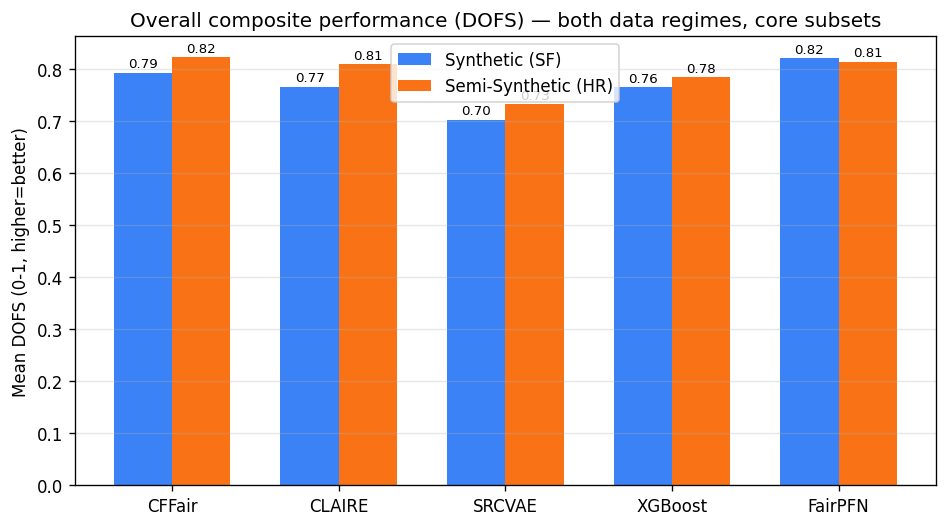

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(MODELS)); w = 0.35
ax.bar(x - w/2, syn_means['DOFS'], width=w, label='Synthetic (SF)', color='#3b82f6')
ax.bar(x + w/2, semi_means['DOFS'], width=w, label='Semi-Synthetic (HR)', color='#f97316')
ax.set_xticks(x); ax.set_xticklabels(MODELS)
ax.set_ylabel('Mean DOFS (0-1, higher=better)')
ax.set_title('Overall composite performance (DOFS) — both data regimes, core subsets')
ax.legend(); ax.grid(alpha=0.3, axis='y')
for i, v in enumerate(syn_means['DOFS']): ax.text(i - w/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)
for i, v in enumerate(semi_means['DOFS']): ax.text(i + w/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'dofs_final_comparison.png'))
plt.show()


## 12. Sensitivity Analysis (Appendix A)

What drives DOFS: `HistGradientBoostingRegressor` + permutation importance per regime.

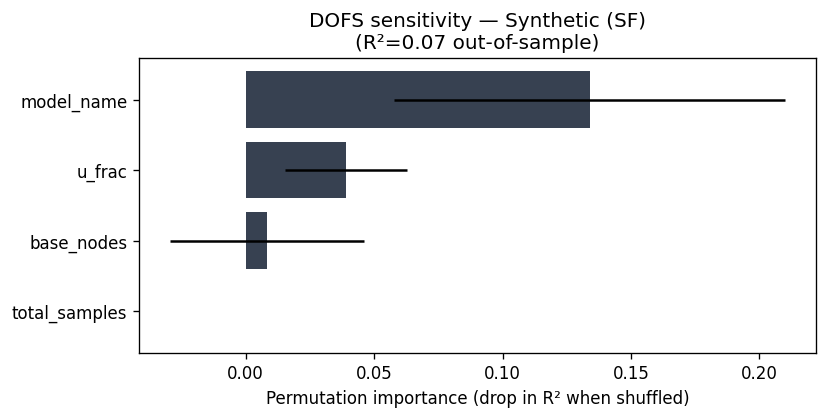

SF importance: {'model_name': 0.134, 'base_nodes': 0.0082, 'u_frac': 0.0391, 'total_samples': 0.0}  R2: 0.067


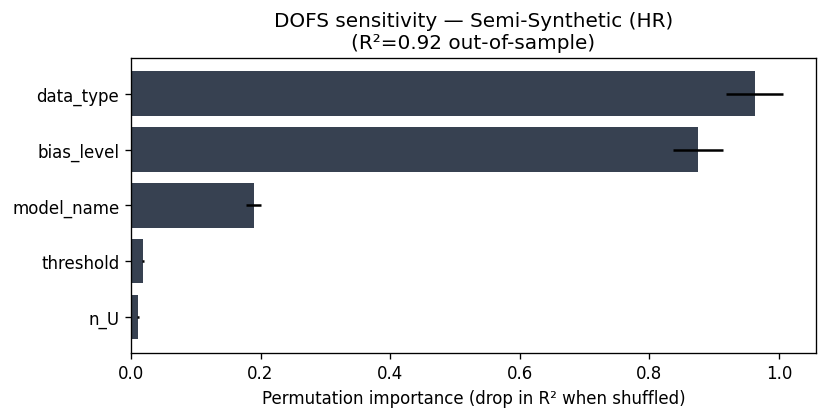

HR importance: {'model_name': 0.1893, 'bias_level': 0.8749, 'data_type': 0.9629, 'threshold': 0.0188, 'n_U': 0.0113}  R2: 0.92


In [26]:
def run_importance(df, features, target, cat_features, title, fname):
    d = df[features + [target]].dropna().copy()
    for c in cat_features:
        d[c] = d[c].astype('category').cat.codes
    X = d[features]; y = d[target]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42)
    model = HistGradientBoostingRegressor(random_state=42, max_depth=4)
    model.fit(Xtr, ytr)
    r2 = model.score(Xte, yte)
    imp = permutation_importance(model, Xte, yte, n_repeats=20, random_state=42)
    order = np.argsort(imp.importances_mean)[::-1]
    fig, ax = plt.subplots(figsize=(7, 3.6))
    ax.barh([features[i] for i in order][::-1], imp.importances_mean[order][::-1],
            xerr=imp.importances_std[order][::-1], color='#374151')
    ax.set_xlabel('Permutation importance (drop in R\u00b2 when shuffled)')
    ax.set_title(f'{title}\n(R\u00b2={r2:.2f} out-of-sample)', fontsize=12)
    plt.tight_layout(); plt.savefig(fname)
    plt.show()
    return dict(zip(features, imp.importances_mean)), r2

syn_features = ['model_name', 'base_nodes', 'u_frac', 'total_samples']
imp_syn, r2_syn = run_importance(syn_all, syn_features, 'DOFS', ['model_name'],
                                  'DOFS sensitivity — Synthetic (SF)',
                                  os.path.join(CHARTS_DIR, 'syn_importance.png'))
print('SF importance:', {k: round(v, 4) for k, v in imp_syn.items()}, ' R2:', round(r2_syn, 3))

semi_features = ['model_name', 'bias_level', 'data_type', 'threshold', 'n_U']
imp_semi, r2_semi = run_importance(semi_all, semi_features, 'DOFS', ['model_name', 'bias_level', 'data_type'],
                                    'DOFS sensitivity — Semi-Synthetic (HR)',
                                    os.path.join(CHARTS_DIR, 'semi_importance.png'))
print('HR importance:', {k: round(v, 4) for k, v in imp_semi.items()}, ' R2:', round(r2_semi, 3))


> **Reading the two panels above:** the semi-synthetic model (R²=0.92) reliably explains DOFS variance — its importances are trustworthy. The synthetic model (R²=0.07) explains almost none of the variance out-of-sample; its importance ranking should be treated as indicative at best, not a reliable driver analysis.

### 12.1 Significance threshold for importance scores

Velev & Lessmann (2026) define an explicit threshold (EBM importance ≥ 0.01) to separate "significant driver" from "negligible" in their sensitivity analysis, rather than relying on eyeballing bar heights. Since `permutation_importance` scores aren't on the same scale as EBM's, we adopt the same *principle* with a threshold suited to this metric: a feature counts as a significant driver of DOFS if its importance is **≥ 10% of the largest importance in that panel** — a relative, self-consistent cutoff rather than an arbitrary absolute number.

In [27]:
def flag_significant(importances, rel_threshold=0.10):
    """
    Flags features whose importance is at least `rel_threshold` of the largest
    importance in the same panel -- the relative analogue of the paper's fixed
    0.01 EBM-importance cutoff, adapted since permutation importance isn't on
    the same scale as EBM importance.
    """
    max_imp = max(importances.values())
    cutoff = rel_threshold * max_imp
    return {k: (v, v >= cutoff) for k, v in importances.items()}

print('=== Synthetic (SF): significant drivers of DOFS (>= 10% of max importance) ===')
for k, (v, sig) in flag_significant(imp_syn).items():
    print(f"  {k}: {v:.4f} {'[SIGNIFICANT]' if sig else ''}")

print()
print('=== Semi-Synthetic (HR): significant drivers of DOFS (>= 10% of max importance) ===')
for k, (v, sig) in flag_significant(imp_semi).items():
    print(f"  {k}: {v:.4f} {'[SIGNIFICANT]' if sig else ''}")


=== Synthetic (SF): significant drivers of DOFS (>= 10% of max importance) ===
  model_name: 0.1340 [SIGNIFICANT]
  base_nodes: 0.0082 
  u_frac: 0.0391 [SIGNIFICANT]
  total_samples: 0.0000 

=== Semi-Synthetic (HR): significant drivers of DOFS (>= 10% of max importance) ===
  model_name: 0.1893 [SIGNIFICANT]
  bias_level: 0.8749 [SIGNIFICANT]
  data_type: 0.9629 [SIGNIFICANT]
  threshold: 0.0188 
  n_U: 0.0113 


### 12.2 Interaction effects (model × scenario), as line overlays — not heatmaps

Same chart language as the combined-overlay sections above, so the interaction view stays visually consistent with the rest of the notebook.

> **Note on methodology:** Velev & Lessmann detect interaction effects *statistically*, via EBM's built-in pairwise interaction terms. That mechanism isn't available with the `HistGradientBoostingRegressor` substitute used in section 8 (EBM's package needs network access unavailable here). This section instead visualizes two interactions chosen manually based on domain relevance (`model × bias_level`, `model × u_frac`) rather than ones statistically discovered — a disclosed simplification, not a full replication of the paper's interaction-detection step.

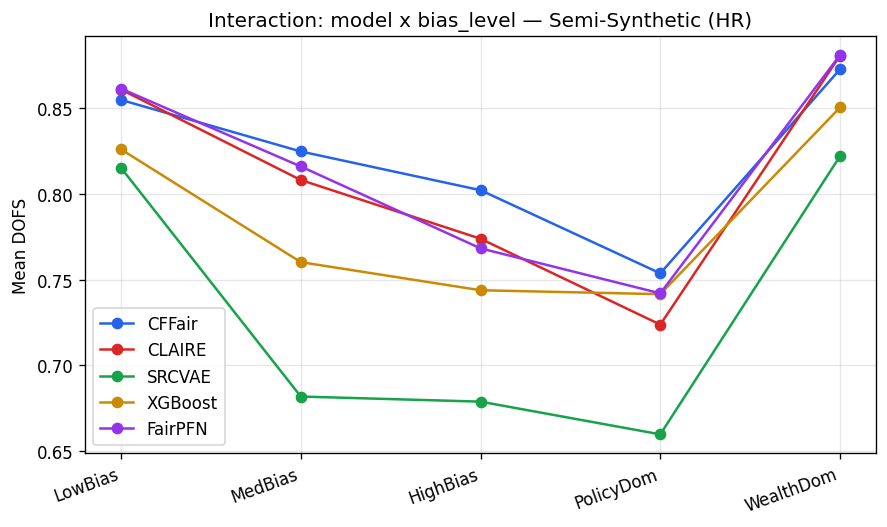

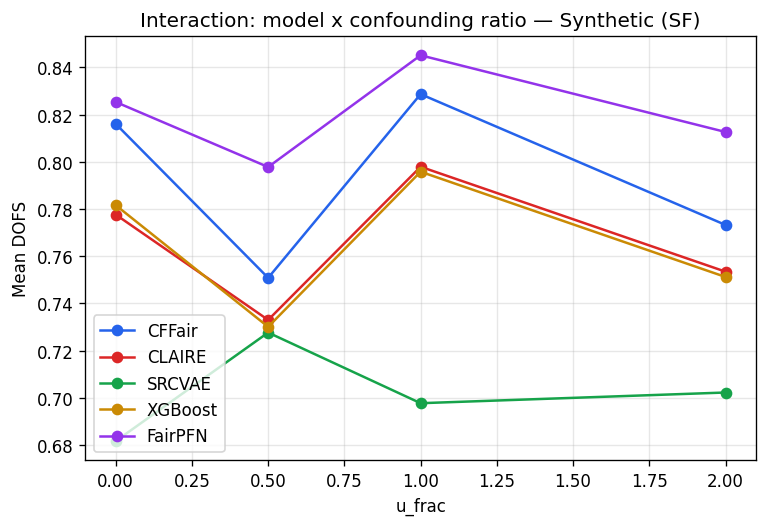

In [28]:
core = semi_all[(semi_all.data_type.isin(['BIASED_ALL', 'FAIR_ALL'])) & (semi_all.n_U == 4)]
piv = core.groupby(['model_name', 'bias_level'])['DOFS'].mean().unstack().reindex(MODELS)[BIAS_ORDER]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for model in MODELS:
    ax.plot(range(len(BIAS_ORDER)), piv.loc[model].values, marker='o', color=COLORS[model], label=model)
ax.set_xticks(range(len(BIAS_ORDER))); ax.set_xticklabels(BIAS_ORDER, rotation=20, ha='right')
ax.set_ylabel('Mean DOFS'); ax.set_title('Interaction: model x bias_level — Semi-Synthetic (HR)')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_interaction_model_bias.png'))
plt.show()

core2 = syn_all[syn_all.u_frac.isin([0.0, 0.5, 1.0, 2.0])]
piv2 = core2.groupby(['model_name', 'u_frac'])['DOFS'].mean().unstack().reindex(MODELS)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for model in MODELS:
    ax.plot(piv2.columns, piv2.loc[model].values, marker='o', color=COLORS[model], label=model)
ax.set_xlabel('u_frac'); ax.set_ylabel('Mean DOFS')
ax.set_title('Interaction: model x confounding ratio — Synthetic (SF)')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'syn_interaction_model_ufrac.png'))
plt.show()


## 13. DOFS_U — Standalone Comparison

An alternate, standalone chart of the DOFS_U pattern already summarised in Part 2, Section 9.8.
`DOFS_U` and `DIR_dist_U` were computed on `syn_core` / `semi_core` in Part 2, Section 9.1 --
this cell only compares and visualizes the columns already present.

Synthetic: n=300 rows used for BOTH columns


,DOFS,DOFS_U
model_name,,
CFFair,0.784,0.667
CLAIRE,0.761,0.654
SRCVAE,0.709,0.678
XGBoost,0.759,0.663
FairPFN,0.819,0.673



Semi-Synthetic: n=4000 rows used for BOTH columns


,DOFS,DOFS_U
model_name,,
CFFair,0.822,0.773
CLAIRE,0.809,0.782
SRCVAE,0.732,0.726
XGBoost,0.784,0.760
FairPFN,0.814,0.777


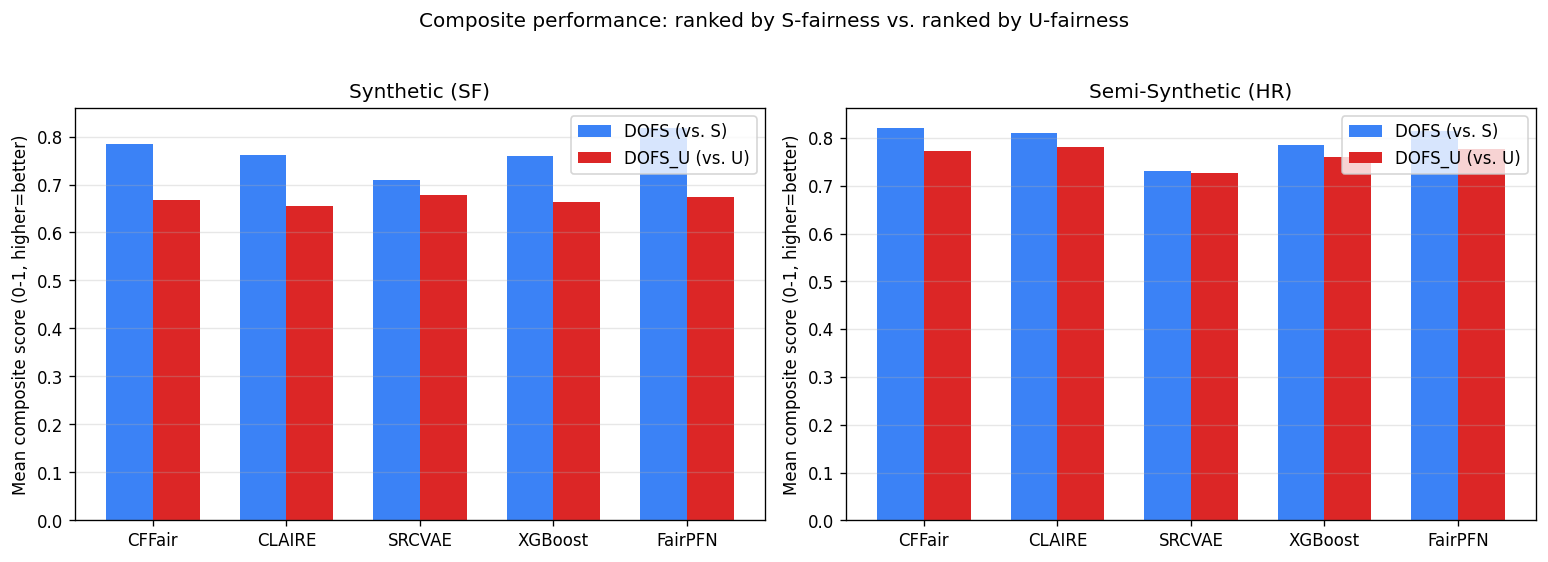

In [29]:
def dofs_compare_matched(df, label):
    matched = df.dropna(subset=['DOFS_U']).copy()
    means = matched.groupby('model_name')[['DOFS', 'DOFS_U']].mean().reindex(MODELS)
    print(f'{label}: n={len(matched)} rows used for BOTH columns')
    display(means.round(3))
    means.to_csv(os.path.join(TABLES_DIR, f'dofs_vs_dofs_u_matched_{label.replace(" ", "_").lower()}.csv'))
    return means

# DOFS_U was already computed on syn_core/semi_core in Part 2, Section 9.1 (add_dofs_u) --
# this cell just compares and visualizes it, no recomputation needed.
dofs_compare_syn = dofs_compare_matched(syn_core, 'Synthetic')
print()
dofs_compare_semi = dofs_compare_matched(semi_core, 'Semi-Synthetic')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(MODELS)); w = 0.35

axes[0].bar(x - w/2, dofs_compare_syn['DOFS'], width=w, label='DOFS (vs. S)', color='#3b82f6')
axes[0].bar(x + w/2, dofs_compare_syn['DOFS_U'], width=w, label='DOFS_U (vs. U)', color='#dc2626')
axes[0].set_xticks(x); axes[0].set_xticklabels(MODELS)
axes[0].set_ylabel('Mean composite score (0-1, higher=better)')
axes[0].set_title('Synthetic (SF)'); axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(x - w/2, dofs_compare_semi['DOFS'], width=w, label='DOFS (vs. S)', color='#3b82f6')
axes[1].bar(x + w/2, dofs_compare_semi['DOFS_U'], width=w, label='DOFS_U (vs. U)', color='#dc2626')
axes[1].set_xticks(x); axes[1].set_xticklabels(MODELS)
axes[1].set_ylabel('Mean composite score (0-1, higher=better)')
axes[1].set_title('Semi-Synthetic (HR)'); axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Composite performance: ranked by S-fairness vs. ranked by U-fairness', y=1.03)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'dofs_vs_dofs_u.png'))
plt.show()


## 14. Weight-Sensitivity Robustness Check

Velev & Lessmann's DOS gives all criteria equal weight by default but explicitly demonstrate
(Appendix I) that their model ranking is robust to alternative weighting schemes. This repeats
that check here: DOFS is recomputed under three weighting schemes — equal weights (the default
used throughout this notebook), fairness-weighted (fairness criteria count 2x), and
predictive-weighted (predictive criteria count 2x) — and checks whether the top-ranked model
changes.

In [30]:
def weighted_dofs(df, maximize_cols, minimize_cols, weights):
    """
    Generalizes add_dofs() to accept a per-metric weight dict. Equal weights
    (1.0 for every metric) reproduces the original unweighted DOFS exactly.
    """
    best_components, worst_components = [], []
    for c in maximize_cols:
        w = weights.get(c, 1.0)
        best_components.append(w * (1 - df[c]) ** 2)
        worst_components.append(w * (0 - df[c]) ** 2)
    for c in minimize_cols:
        w = weights.get(c, 1.0)
        v = df[c + '_clip']
        best_components.append(w * (0 - v) ** 2)
        worst_components.append(w * (1 - v) ** 2)
    dist_best = np.sqrt(sum(best_components))
    dist_worst = np.sqrt(sum(worst_components))
    return dist_worst / (dist_worst + dist_best)


maximize_cols = ['ROC_AUC', 'Accuracy', 'Precision', 'Recall', 'F1_Score']
minimize_cols = ['Statistical_Parity_Diff_(ATE)', 'Equal_Opportunity_Diff', 'DIR_dist']

WEIGHT_SCHEMES = {
    'Equal weights (default)': {**{c: 1.0 for c in maximize_cols}, **{c: 1.0 for c in minimize_cols}},
    'Fairness-weighted (2x)':  {**{c: 1.0 for c in maximize_cols}, **{c: 2.0 for c in minimize_cols}},
    'Predictive-weighted (2x)': {**{c: 2.0 for c in maximize_cols}, **{c: 1.0 for c in minimize_cols}},
}

def run_weight_sensitivity(df, core_df, label):
    print(f'=== {label}: mean DOFS and rank (1=best) under each weighting scheme ===')
    rank_table = pd.DataFrame(index=MODELS)
    for scheme_name, weights in WEIGHT_SCHEMES.items():
        core_df = core_df.copy()
        core_df[scheme_name] = weighted_dofs(core_df, maximize_cols, minimize_cols, weights)
        means = core_df.groupby('model_name')[scheme_name].mean().reindex(MODELS)
        rank_table[scheme_name] = means.rank(ascending=False).astype(int)
    display(rank_table)

    top_models = {scheme: rank_table[rank_table[scheme] == 1].index[0] for scheme in WEIGHT_SCHEMES}
    stable = len(set(top_models.values())) == 1
    print(f"Top-ranked model per scheme: {top_models}")
    print(f"{'STABLE' if stable else 'NOT STABLE'} -- top model {'does not change' if stable else 'changes'} across weighting schemes.\n")

    rank_table.to_csv(os.path.join(TABLES_DIR, f'weight_sensitivity_{label.replace(" ", "_").lower()}.csv'))
    return rank_table

weight_ranks_syn = run_weight_sensitivity(syn_all, syn_core, 'Synthetic')
weight_ranks_semi = run_weight_sensitivity(semi_all, semi_core, 'Semi-Synthetic')


=== Synthetic: mean DOFS and rank (1=best) under each weighting scheme ===


,Equal weights (default),Fairness-weighted (2x),Predictive-weighted (2x)
CFFair,2,2,2
CLAIRE,3,3,4
SRCVAE,5,5,5
XGBoost,4,4,3
FairPFN,1,1,1


Top-ranked model per scheme: {'Equal weights (default)': 'FairPFN', 'Fairness-weighted (2x)': 'FairPFN', 'Predictive-weighted (2x)': 'FairPFN'}
STABLE -- top model does not change across weighting schemes.

=== Semi-Synthetic: mean DOFS and rank (1=best) under each weighting scheme ===


,Equal weights (default),Fairness-weighted (2x),Predictive-weighted (2x)
CFFair,1,1,1
CLAIRE,3,3,3
SRCVAE,5,5,5
XGBoost,4,4,4
FairPFN,2,2,2


Top-ranked model per scheme: {'Equal weights (default)': 'CFFair', 'Fairness-weighted (2x)': 'CFFair', 'Predictive-weighted (2x)': 'CFFair'}
STABLE -- top model does not change across weighting schemes.

